# 14 -- Joint Hurdle Transformer v1

Новый controlled experiment поверх **того же `data/lstm/` pipeline**, что и лучший `Joint Hurdle BiLSTM v4`.

Текущий reference:

```text
Joint Hurdle BiLSTM expanded ES
mean temporal CV = 1.715708
January RMSLE    = 1.677522
Public RMSLE     = 1.6506631932
```

Здесь намеренно не меняются одновременно и признаки, и target decomposition, и static branch.

Главная замена:

```text
2-layer BiLSTM
      |
      v
3-layer Transformer Encoder
```

Все остальное максимально близко к сильной LSTM:

```text
53 sequence features/day
93 short-summary features
235 static features
gate / positive / direct heads
learned hurdle/direct blend
log1p objective
3-fold expanding temporal CV
early stopping
3 final seeds
```

В отличие от старого LSTM run, **per-user OOF predictions сохраняются сразу для каждой эпохи каждого temporal fold**. После CV exact OOF выбранной эпохи автоматически собирается в `oof_best_epoch.parquet`.

## Вся логика notebook сверху вниз

```text
data/lstm artifacts
        |
        v
90-day history + static snapshot
        |
        +-----------------------------+
        |                             |
        v                             v
53 features/day                 93 short-summary
        |                             |
Linear 53 -> 128                     MLP
        |
learned recency embedding
        |
3 x Transformer Encoder
        |
last + mean + max + attention pooling
        |
sequence repr 144
        |
        +------------------ static 235 -> MLP -> 96
        |                             |
        +------- summary repr 64 -----+
                      |
                   fusion
                      |
                     96
                      |
          +-----------+-----------+
          |           |           |
        gate       positive     direct
          |           |           |
          +-> hurdle <-+           |
                 \                 /
                  \-- learned mix-/
                         |
                      pred_log
                         |
                 MSE vs log1p(y)
                         |
                         v
             3-fold temporal CV
                         |
             local early stopping
                         |
       BEST_EPOCH по common epochs
                         |
        exact selected-epoch OOF
                         |
                         v
            final train from scratch
           seed 42 / 143 / 2026
                         |
             mean three pred_log
                         |
                       expm1
                         |
                     submit
```

### Что выбирает CV

CV **не выбирает финальные веса**.

На каждом temporal fold создается отдельный Transformer и обучается только на прошлых cutoff.

Из CV нужен в первую очередь ответ:

```text
сколько эпох разумно учить эту architecture?
```

То есть `BEST_EPOCH`.

После этого CV weights больше не нужны для final submission. Final models создаются заново и обучаются на всех labeled cutoff.

### Зачем три final seed

Seed меняет:

- initialization;
- порядок shuffled batches;
- dropout masks;
- часть численной стохастики CUDA.

Поэтому три обучения одной architecture дают немного разные `pred_log`.

Мы не можем честно выбрать "лучший seed" без отдельного validation, поэтому:

```text
seed 42
seed 143
seed 2026
```

все входят в ensemble.

Финальный прогноз:

$$
\hat z =
\frac{
\hat z_{42}+\hat z_{143}+\hat z_{2026}
}{3},
$$

где $\hat z=\log(1+\hat y)$.

После усреднения:

$$
\hat y = \exp(\hat z)-1.
$$

## Важно для Colab

Crash-safe checkpointing помогает только пока сами файлы `models/transformer_hurdle_v1/` не исчезли.

Если Colab runtime может быть уничтожен, каталог `models/` нужно держать на Google Drive или регулярно копировать туда.

Иначе `/content/.../resume.pt` пропадет вместе с runtime, даже если notebook правильно сохранял checkpoint после каждой эпохи.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/Colab-Notebooks/E-CUP-2026

/content/drive/MyDrive/Colab-Notebooks/E-CUP-2026


In [5]:
from pathlib import Path
import contextlib
import hashlib
import json
import math
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch import nn
from torch.utils.data import ConcatDataset, DataLoader, Dataset


def find_project_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "data" / "lstm" / "meta.json").exists():
            return path

    raise FileNotFoundError(
        "Не найден data/lstm/meta.json. "
        "Сначала нужны artifacts из 06_LSTM_Data_Preparation.ipynb."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "lstm"
MODEL_DIR = PROJECT_ROOT / "models" / "transformer_hurdle_v1"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / "meta.json", encoding="utf-8") as f:
    META = json.load(f)

if META.get("format_version") != 2:
    raise RuntimeError(
        "Transformer ожидает data format v2. "
        "Перезапустите актуальный 06_LSTM_Data_Preparation.ipynb."
    )

LABELED_CUTOFFS = META["labeled_cutoffs"]
INFERENCE_CUTOFF = META["inference_cutoff"]
BASE_SEQUENCE_FEATURES = META["base_sequence_features"]
CALENDAR_FEATURES = META["calendar_sequence_features"]
RAW_STATIC_FEATURES = META["static_features"]
RAW_STATIC_LOG_FEATURES = META["static_log_copy_features"]
EXTRA_STATIC_FEATURES = set(META.get("extra_static_features", []))

SEQ_LEN = int(META["seq_len"])
N_USERS = int(META["user_count"])

BASE_INDEX = {
    name: i
    for i, name in enumerate(BASE_SEQUENCE_FEATURES)
}


# -----------------------------------------------------------------------------
# Architecture flags.
# -----------------------------------------------------------------------------

# Первый Transformer run делаю controlled:
# меняется temporal encoder, остальные сильные LSTM-настройки сохраняются.
USE_USER_EMBEDDING = False
USER_EMBED_DIM = 4

USE_ABSOLUTE_TIME = True
USE_FUTURE_CALENDAR_STATIC = False
USE_CUTOFF_SEASONAL_STATIC = False


# -----------------------------------------------------------------------------
# Training config.
# -----------------------------------------------------------------------------

BATCH_SIZE = 16384

MAX_CV_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 8
EARLY_STOPPING_MIN_DELTA = 1e-4
MIN_CV_EPOCHS_BEFORE_STOP = 8
N_CV_FOLDS = 3

LR = 2.0e-4
EMBED_LR = 1.0e-4
WEIGHT_DECAY = 1.0e-2
EMBED_WEIGHT_DECAY = 8.0e-3
ADAM_BETAS = (0.9, 0.95)

RANDOM_STATE = 42
FINAL_SEEDS = [42, 143, 2026]

AUX_GATE_WEIGHT = 0.03
AUX_POS_WEIGHT = 0.10
AUX_DIRECT_WEIGHT = 0.05

# В этом notebook OOF сохраняется сразу на каждой эпохе каждого fold.
SAVE_ALL_CV_PREDICTIONS = True

# Reference -- последний законченный Joint Hurdle BiLSTM expanded-ES run.
REFERENCE_MEAN_CV_RMSLE = 1.715708
REFERENCE_JAN_HOLDOUT_RMSLE = 1.677522
REFERENCE_PUBLIC_RMSLE = 1.6506631932

# Не скипаю final автоматически: у LSTM разница ~1e-3 local CV
# уже плохо предсказывала public.
AUTO_SKIP_FINAL_IF_WEAK = False
FORCE_FINAL_TRAIN = False


# -----------------------------------------------------------------------------
# Device / AMP.
# -----------------------------------------------------------------------------

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

NUM_WORKERS = 4 if DEVICE.type == "cuda" else 0
USE_AMP = DEVICE.type == "cuda"

if USE_AMP:
    AMP_DTYPE = (
        torch.bfloat16
        if torch.cuda.is_bf16_supported()
        else torch.float16
    )
else:
    AMP_DTYPE = None

if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def capture_rng_state():
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
    }

    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()

    return state


def restore_rng_state(state):
    if not state:
        return

    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"])

    if torch.cuda.is_available() and state.get("cuda") is not None:
        try:
            torch.cuda.set_rng_state_all(state["cuda"])
        except Exception:
            print(
                "WARNING: CUDA RNG state could not be restored. "
                "Resume remains valid but not bit-exact."
            )


def choose_static_features():
    selected = []

    for name in RAW_STATIC_FEATURES:
        if name not in EXTRA_STATIC_FEATURES:
            selected.append(name)
            continue

        if name == "cutoff_time_years" and USE_ABSOLUTE_TIME:
            selected.append(name)

        elif name.startswith("forecast_") and USE_FUTURE_CALENDAR_STATIC:
            selected.append(name)

        elif (
            name.startswith("cutoff_")
            and name != "cutoff_time_years"
            and USE_CUTOFF_SEASONAL_STATIC
        ):
            selected.append(name)

    return selected


STATIC_FEATURES = choose_static_features()

STATIC_INDICES = np.array(
    [RAW_STATIC_FEATURES.index(name) for name in STATIC_FEATURES],
    dtype=np.int64,
)

STATIC_LOG_FEATURES = [
    name
    for name in RAW_STATIC_LOG_FEATURES
    if name in STATIC_FEATURES
]

STATIC_LOG_INDICES = [
    STATIC_FEATURES.index(name)
    for name in STATIC_LOG_FEATURES
]

set_seed()

print("device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        f"{torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GB",
    )

print("AMP:", USE_AMP, AMP_DTYPE)
print("batch size:", BATCH_SIZE)
print("labeled cutoffs:", LABELED_CUTOFFS)
print("CV validation cutoffs:", LABELED_CUTOFFS[-N_CV_FOLDS:])
print("inference cutoff:", INFERENCE_CUTOFF)
print("users:", N_USERS)
print("static features:", len(STATIC_FEATURES), "/", len(RAW_STATIC_FEATURES))
print("user embedding:", USE_USER_EMBEDDING)
print("max CV epochs:", MAX_CV_EPOCHS)
print("early stopping patience:", EARLY_STOPPING_PATIENCE)
print("save all CV predictions:", SAVE_ALL_CV_PREDICTIONS)
print("model dir:", MODEL_DIR)

device: cuda
GPU: NVIDIA A100-SXM4-40GB
GPU memory: 39.5 GB
AMP: True torch.bfloat16
batch size: 16384
labeled cutoffs: ['2025-04-19', '2025-05-19', '2025-06-18', '2025-07-18', '2025-08-17', '2025-09-16', '2025-10-16', '2025-11-15', '2025-12-15', '2026-01-14']
CV validation cutoffs: ['2025-11-15', '2025-12-15', '2026-01-14']
inference cutoff: 2026-02-13
users: 250000
static features: 92 / 103
user embedding: False
max CV epochs: 30
early stopping patience: 8
save all CV predictions: True
model dir: /content/drive/MyDrive/Colab-Notebooks/E-CUP-2026/models/transformer_hurdle_v1


## 1. Dataset и variable-length history

Notebook использует уже подготовленные artifacts из `06_LSTM_Data_Preparation.ipynb`.

Для каждого `user_id x cutoff` читаются:

```text
X.npy              -- 90 x 13 behavioral channels
calendar.npy       -- 90 x 6 calendar channels
static.npy         -- snapshot пользователя
history_length.npy -- реальная длина history
user_id.npy
user_index.npy
y.npy               -- GMV следующих 30 дней для labeled cutoff
```

Одна sample -- один пользователь на одном temporal cutoff.

### Padding

Не у каждого пользователя существует полная история в 90 дней.

Например:

```text
|------ artificial padding ------|--- real 35 days ---|
```

Нули в padding нельзя трактовать как "пользователь реально был неактивен".

`history_length` позволяет:

- отличить padding от настоящих нулей;
- compact'нуть реальные дни;
- построить `src_key_padding_mask`;
- исключить padding из mean/max/attention pooling.

После compaction Transformer получает:

```text
|--- real history ---|--- padding ---|
```

Для padding `key_padding_mask=True`, поэтому такие позиции не используются как keys/values self-attention.

In [6]:
def known_user_mask_from_cutoffs(cutoffs):
    mask = np.zeros(N_USERS, dtype=np.bool_)
    for cutoff in cutoffs:
        idx = np.load(DATA_DIR / cutoff / "user_index.npy", mmap_mode="r")
        mask[np.asarray(idx, dtype=np.int64)] = True
    return mask


class HybridDataset(Dataset):
    def __init__(self, cutoff, with_target=True, known_user_mask=None):
        path = DATA_DIR / cutoff
        self.X = np.load(path / "X.npy", mmap_mode="r")
        self.static = np.load(path / "static.npy", mmap_mode="r")
        self.calendar = np.load(path / "calendar.npy", mmap_mode="r").astype(np.float32)
        self.users = np.load(path / "user_id.npy", mmap_mode="r")
        self.user_index = np.load(path / "user_index.npy", mmap_mode="r")
        self.history_length = np.load(path / "history_length.npy", mmap_mode="r")
        self.y = np.load(path / "y.npy", mmap_mode="r") if with_target else None
        self.known_user_mask = known_user_mask

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        sequence = np.concatenate([
            np.asarray(self.X[i], dtype=np.float32),
            self.calendar,
        ], axis=1)

        user_index = int(self.user_index[i])
        user_known = True if self.known_user_mask is None else bool(self.known_user_mask[user_index])

        raw_static = np.asarray(self.static[i], dtype=np.float32)
        static = raw_static[STATIC_INDICES]

        result = (
            torch.from_numpy(sequence),
            torch.from_numpy(static),
            torch.tensor(user_index, dtype=torch.long),
            torch.tensor(user_known, dtype=torch.bool),
            torch.tensor(int(self.history_length[i]), dtype=torch.long),
        )

        if self.y is None:
            return result

        return (*result, torch.tensor(float(self.y[i]), dtype=torch.float32))


def make_loader(
    cutoffs,
    shuffle=False,
    with_target=True,
    batch_size=BATCH_SIZE,
    known_user_mask=None,
):
    if isinstance(cutoffs, str):
        cutoffs = [cutoffs]

    dataset = ConcatDataset([
        HybridDataset(
            cutoff,
            with_target=with_target,
            known_user_mask=known_user_mask,
        )
        for cutoff in cutoffs
    ])

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
        drop_last=False,
    )

## 2. Sequence features -- те же 53 признака на день

Feature engineering намеренно совпадает с LSTM, чтобы сравнение было максимально чистым.

### 19 исходных каналов

```text
13 behavioral / GMV
+
6 calendar sin/cos
```

### +34 derived features

На батче добавляются:

- valid-history mask;
- relative history position;
- normalized days to cutoff;
- event flags;
- conversion ratios;
- rolling mean 3/7/14/30;
- rolling activity rate 3/7/14/30;
- first differences.

Все rolling operations используют только историю до cutoff.

Итог:

```text
batch x 90 x 53
```

## Short-summary -- 93 признака

Отдельная branch дает Transformer явные простые агрегаты:

- суммы по окнам 1/3/7/14/30/60/90;
- activity rate;
- days since last event;
- recent minus previous window;
- 30-day buckets;
- purchase periodicity;
- history length.

Идея:

```text
Transformer
-> сложные взаимодействия между днями

summary MLP
-> готовые recency / frequency statistics
```

Transformer теоретически может сам вывести большую часть этих агрегатов, но forcing ему на это тратить capacity обычно бессмысленно.

In [7]:
def history_mask_from_lengths(lengths, steps=SEQ_LEN):
    positions = torch.arange(steps, device=lengths.device).unsqueeze(0)
    starts = steps - lengths.unsqueeze(1)
    return positions >= starts


def causal_masked_mean(values, valid_mask, window):
    values = values * valid_mask
    num = F.avg_pool1d(
        F.pad(values.unsqueeze(1), (window - 1, 0)),
        window,
        stride=1,
    ).squeeze(1) * window
    den = F.avg_pool1d(
        F.pad(valid_mask.unsqueeze(1), (window - 1, 0)),
        window,
        stride=1,
    ).squeeze(1) * window
    return num / den.clamp_min(1.0)


def first_difference(values, valid_mask):
    previous_valid = F.pad(valid_mask[:, :-1], (1, 0))
    both_valid = valid_mask * previous_valid
    diff = F.pad(values[:, 1:] - values[:, :-1], (1, 0))
    return diff * both_valid


def safe_ratio(numerator, denominator, max_value=5.0):
    ratio = numerator / denominator.clamp_min(1e-3)
    ratio = torch.where(denominator > 0, ratio, torch.zeros_like(ratio))
    return ratio.clamp(0, max_value)


def make_sequence_features(x, lengths):
    steps = x.shape[1]
    valid_mask = history_mask_from_lengths(lengths, steps).float()

    searches_log = x[..., BASE_INDEX["searches"]]
    search_to_cart_log = x[..., BASE_INDEX["search_to_cart"]]
    search_to_ord_log = x[..., BASE_INDEX["search_to_ord"]]
    cat_to_cart_log = x[..., BASE_INDEX["cat_to_cart"]]
    cat_to_ord_log = x[..., BASE_INDEX["cat_to_ord"]]
    to_cart_log = x[..., BASE_INDEX["to_cart"]]
    to_ord_log = x[..., BASE_INDEX["to_ord"]]
    gmv_search_log = x[..., BASE_INDEX["gmv_search"]]
    gmv_log = x[..., BASE_INDEX["gmv"]]
    active = x[..., BASE_INDEX["active"]]

    searches = torch.expm1(searches_log).clamp_min(0)
    search_to_cart = torch.expm1(search_to_cart_log).clamp_min(0)
    search_to_ord = torch.expm1(search_to_ord_log).clamp_min(0)
    cat_to_cart = torch.expm1(cat_to_cart_log).clamp_min(0)
    cat_to_ord = torch.expm1(cat_to_ord_log).clamp_min(0)
    to_cart = torch.expm1(to_cart_log).clamp_min(0)
    to_ord = torch.expm1(to_ord_log).clamp_min(0)
    gmv_search = torch.expm1(gmv_search_log).clamp_min(0)
    gmv = torch.expm1(gmv_log).clamp_min(0)

    positions = torch.arange(steps, device=x.device).float().unsqueeze(0)
    starts = (steps - lengths).float().unsqueeze(1)
    denom = (lengths.float() - 1).clamp_min(1.0).unsqueeze(1)

    relative_history_position = ((positions - starts) / denom).clamp(0, 1) * valid_mask
    days_to_cutoff = ((steps - 1 - positions) / max(steps - 1, 1)) * valid_mask

    derived = [
        valid_mask,
        relative_history_position,
        days_to_cutoff,
        (search_to_cart > 0).float(),
        (search_to_ord > 0).float(),
        (cat_to_cart > 0).float(),
        (cat_to_ord > 0).float(),
        safe_ratio(search_to_cart, searches),
        safe_ratio(search_to_ord, searches),
        safe_ratio(to_ord, to_cart),
        safe_ratio(gmv_search, gmv, 1.5),
    ]

    for values in [searches_log, to_cart_log, to_ord_log, gmv_log]:
        for window in [3, 7, 14, 30]:
            derived.append(causal_masked_mean(values, valid_mask, window))

    for window in [3, 7, 14, 30]:
        derived.append(causal_masked_mean(active, valid_mask, window))

    for values in [searches_log, to_ord_log, gmv_log]:
        derived.append(first_difference(values, valid_mask))

    return torch.cat([x, torch.stack(derived, dim=-1)], dim=-1)


def _raw_channel(x, feature_name):
    return torch.expm1(x[..., BASE_INDEX[feature_name]]).clamp_min(0)


def _window_raw_sum(x, feature_name, window):
    return _raw_channel(x, feature_name)[:, -window:].sum(dim=1)


def _slice_raw_sum(x, feature_name, start_from_end, end_from_end):
    values = _raw_channel(x, feature_name)
    left = x.shape[1] - start_from_end
    right = x.shape[1] - end_from_end if end_from_end > 0 else x.shape[1]
    return values[:, max(left, 0):max(right, 0)].sum(dim=1)


def _days_since_event(x, lengths, feature_name):
    values = _raw_channel(x, feature_name)
    valid = history_mask_from_lengths(lengths, x.shape[1])
    event = (values > 0) & valid
    positions = torch.arange(x.shape[1], device=x.device).unsqueeze(0).expand_as(values)
    last = torch.where(event, positions, torch.full_like(positions, -1)).amax(dim=1)
    days = (x.shape[1] - 1 - last).float()
    return torch.where(last >= 0, days / x.shape[1], torch.full_like(days, 1.25))


def _purchase_periodicity(x, lengths):
    values = _raw_channel(x, "to_ord")
    valid = history_mask_from_lengths(lengths, x.shape[1])
    event = (values > 0) & valid

    positions = torch.arange(x.shape[1], device=x.device).unsqueeze(0).expand_as(values)
    masked_pos = torch.where(event, positions, torch.full_like(positions, -1))
    top2 = torch.topk(masked_pos, k=2, dim=1).values
    last = top2[:, 0]
    previous = top2[:, 1]

    has_any = last >= 0
    has_two = previous >= 0

    days_since = torch.where(
        has_any,
        (x.shape[1] - 1 - last).float() / x.shape[1],
        torch.full_like(last.float(), 1.25),
    )
    last_gap = torch.where(
        has_two,
        (last - previous).float() / x.shape[1],
        torch.ones_like(last.float()),
    )
    event_rate = event.sum(dim=1).float() / lengths.float().clamp_min(1.0)
    phase = torch.where(
        has_two,
        days_since / last_gap.clamp_min(1.0 / x.shape[1]),
        torch.ones_like(days_since),
    ).clamp(0, 5)

    return [event_rate, days_since, last_gap, phase, has_two.float()]


def make_short_summary(x, lengths):
    windows = [1, 3, 7, 14, 30, 60, 90]
    volume_names = ["searches", "to_cart", "to_ord", "gmv", "gmv_search"]
    features = []

    for name in volume_names:
        for window in windows:
            features.append(torch.log1p(_window_raw_sum(x, name, window)))

    active = x[..., BASE_INDEX["active"]]
    for window in windows:
        exposure = lengths.clamp(max=window).float()
        features.append(active[:, -window:].sum(dim=1) / exposure.clamp_min(1.0))

    for name in volume_names:
        features.append(_days_since_event(x, lengths, name))

    for name in volume_names:
        values = _raw_channel(x, name)
        for window in [3, 7, 14, 30]:
            recent = values[:, -window:].sum(dim=1)
            previous = values[:, -2 * window:-window].sum(dim=1)
            features.append(torch.log1p(recent) - torch.log1p(previous))

    for name in volume_names:
        buckets = [
            _slice_raw_sum(x, name, 30, 0),
            _slice_raw_sum(x, name, 60, 30),
            _slice_raw_sum(x, name, 90, 60),
        ]
        bucket_logs = [torch.log1p(v) for v in buckets]
        features.extend(bucket_logs)
        features.append(bucket_logs[0] - bucket_logs[2])

    features.extend(_purchase_periodicity(x, lengths))
    features.append(lengths.float() / x.shape[1])

    return torch.stack(features, dim=1)


with torch.no_grad():
    dummy_x = torch.zeros(
        2,
        SEQ_LEN,
        len(BASE_SEQUENCE_FEATURES) + len(CALENDAR_FEATURES),
        dtype=torch.float32,
    )
    dummy_lengths = torch.tensor([SEQ_LEN, max(2, SEQ_LEN // 2)], dtype=torch.long)
    SEQ_INPUT_SIZE = int(make_sequence_features(dummy_x, dummy_lengths).shape[-1])
    SHORT_SUMMARY_SIZE = int(make_short_summary(dummy_x, dummy_lengths).shape[-1])

print("sequence features:", SEQ_INPUT_SIZE)
print("short summary:", SHORT_SUMMARY_SIZE)

sequence features: 53
short summary: 93


## 3. Static preprocessing -- 235 признаков без temporal leakage

Static branch совпадает с сильной LSTM.

В текущей конфигурации:

```text
92 selected raw static
+ 51 log1p heavy-tail copies
+ 92 missing masks
= 235
```

### Почему normalization fit'ится отдельно на каждом CV fold

Нельзя fit'нуть mean/std на всех месяцах перед temporal CV.

Иначе distribution будущего validation месяца попадет в preprocessing прошлого.

Правильно:

```text
Fold Nov:
fit stats Apr..Oct
transform train + Nov

Fold Dec:
fit stats Apr..Nov
transform train + Dec

Fold Jan:
fit stats Apr..Dec
transform train + Jan
```

Final model уже fit'ит static stats на **всех labeled cutoff**, потому что после выбора `BEST_EPOCH` отдельного validation месяца больше нет.

In [8]:
STATIC_INPUT_SIZE = 2 * len(STATIC_FEATURES) + len(STATIC_LOG_INDICES)


def augment_static_numpy(raw):
    raw = np.asarray(raw, dtype=np.float32)
    source = raw[:, STATIC_LOG_INDICES]
    logs = np.where(
        np.isfinite(source),
        np.log1p(np.clip(source, 0, None)),
        np.nan,
    ).astype(np.float32)
    missing = (~np.isfinite(raw)).astype(np.float32)
    return np.concatenate([raw, logs, missing], axis=1)


def fit_static_stats(cutoffs, chunk_size=65_536):
    sums = np.zeros(STATIC_INPUT_SIZE, dtype=np.float64)
    sums_sq = np.zeros(STATIC_INPUT_SIZE, dtype=np.float64)
    counts = np.zeros(STATIC_INPUT_SIZE, dtype=np.int64)

    for cutoff in cutoffs:
        raw_full = np.load(DATA_DIR / cutoff / "static.npy", mmap_mode="r")
        for start in range(0, len(raw_full), chunk_size):
            raw = np.asarray(raw_full[start:start + chunk_size], dtype=np.float32)[:, STATIC_INDICES]
            block = augment_static_numpy(raw)
            finite = np.isfinite(block)
            safe = np.where(finite, block, 0.0).astype(np.float64)
            sums += safe.sum(axis=0)
            sums_sq += (safe * safe).sum(axis=0)
            counts += finite.sum(axis=0)

    counts = np.maximum(counts, 1)
    mean = sums / counts
    std = np.sqrt(np.maximum(sums_sq / counts - mean * mean, 1e-6))
    return (
        torch.tensor(mean, dtype=torch.float32),
        torch.tensor(std, dtype=torch.float32),
    )


def normalize_static(raw, stats):
    source = raw[:, STATIC_LOG_INDICES]
    logs = torch.where(
        torch.isfinite(source),
        torch.log1p(source.clamp_min(0)),
        torch.nan,
    )
    augmented = torch.cat([raw, logs, (~torch.isfinite(raw)).float()], dim=1)

    mean, std = stats
    mean = mean.to(raw.device)
    std = std.to(raw.device)

    augmented = torch.where(torch.isfinite(augmented), augmented, mean)
    return (augmented - mean) / std


print("static features after augmentation:", STATIC_INPUT_SIZE)

static features after augmentation: 235


## 4. Transformer Encoder -- архитектура максимально подробно

Основное отличие этой модели от LSTM находится здесь.

### 4.1 Token каждого дня

После feature engineering один день представлен 53 числами:

```text
x_t in R^53
```

Первый слой:

```text
Linear(53 -> 128)
LayerNorm
GELU
```

получает token embedding:

```text
h_t in R^128
```

То есть каждый из 90 дней становится 128-мерным vector.

### 4.2 Почему нужен positional signal

Чистый self-attention не знает порядок элементов.

Без positional information набор:

```text
день A, день B, день C
```

математически почти неотличим от перестановки:

```text
день C, день A, день B
```

У нас позиция уже частично находится среди numeric features:

```text
relative_history_position
days_to_cutoff
calendar sin/cos
```

Но дополнительно используется learned `recency_embedding`.

Индекс:

```text
0  -> самый свежий реальный день
1  -> один день до него
...
89 -> самый старый
```

Он складывается с projected token.

Получается два разных positional сигнала:

```text
continuous numeric position
+
learned discrete recency embedding
```

### 4.3 Self-attention -- Q, K, V

Внутри attention из token representations $X$ строятся:

$$
Q=XW_Q,
$$

$$
K=XW_K,
$$

$$
V=XW_V.
$$

$W_Q$, $W_K$, $W_V$ -- обучаемые матрицы.

Score между query одного дня и key другого:

$$
S=
\frac{QK^T}{\sqrt{d_k}}.
$$

После softmax:

$$
A=softmax(S).
$$

И новый representation:

$$
Attention(Q,K,V)=AV.
$$

Интуитивно:

```text
Q -- что текущий день хочет найти?
K -- по каким признакам другой день можно найти?
V -- какую информацию из найденного дня забрать?
```

### 4.4 Multi-head attention

Параметры:

```text
d_model = 128
n_heads = 8
head_dim = 16
```

128 channels делятся на 8 heads.

У каждого head собственные projections.

Это позволяет разным heads специализироваться на разных temporal relations.

Например, концептуально один head может ловить:

```text
purchase recency
```

другой:

```text
weekly repeated activity
```

третий:

```text
search spike -> future order inside history
```

Это только интуитивная интерпретация -- конкретные patterns сеть выбирает сама.

### 4.5 Почему attention не causal

Мы не генерируем будущее по одному дню.

На forecast cutoff **вся 90-дневная история уже известна**.

Поэтому исторический день может смотреть на любой другой исторический день внутри окна.

Используется bidirectional self-attention:

```text
past history <-> past history
```

Leakage нет, потому что target horizon вообще не входит в input.

### 4.6 Padding mask

`src_key_padding_mask=True` запрещает attention использовать artificial padding как key/value.

Это аналогично variable-length masking в LSTM.

### 4.7 Один encoder block

Используется Pre-LN Transformer:

```text
x
|
LayerNorm
|
MultiHeadAttention
|
Dropout
|
+ residual x
|
LayerNorm
|
FFN: 128 -> 384 -> 128
|
Dropout
|
+ residual
```

В формулах:

$$
x_1=x+MHA(LN(x)),
$$

$$
x_2=x_1+FFN(LN(x_1)).
$$

`norm_first=True` означает именно такую Pre-LN схему.

Она обычно стабильнее optimization, поэтому можно обойтись без агрессивного LR warmup.

### 4.8 Три encoder layer

```text
num_layers = 3
```

После первого layer каждый день уже может содержать информацию обо всей истории.

Следующие layers строят более сложные взаимодействия.

Я намеренно не делаю encoder очень глубоким:

- sequence всего 90;
- dataset большой;
- задача regression, не language modeling;
- хочется избежать unnecessary overfit;
- первый run должен быть достаточно быстрым и надежным.

### 4.9 Complexity

Self-attention:

$$
O(T^2d).
$$

У нас:

```text
T = 90
T^2 = 8100
```

Поэтому quadratic attention здесь не проблема.

90 дней -- очень короткая последовательность относительно типичных Transformer задач.

In [9]:
def compact_left_padded(sequence, lengths):
    # Переношу реальные дни в начало, padding -- вправо.
    batch, steps, channels = sequence.shape

    positions = (
        torch.arange(steps, device=sequence.device)
        .unsqueeze(0)
        .expand(batch, -1)
    )

    starts = steps - lengths.unsqueeze(1)
    source_pos = (positions + starts).clamp(max=steps - 1)

    gathered = sequence.gather(
        1,
        source_pos.unsqueeze(-1).expand(-1, -1, channels),
    )

    valid = positions < lengths.unsqueeze(1)

    return gathered * valid.unsqueeze(-1)


class JointHurdleTransformer(nn.Module):
    def __init__(
        self,
        n_users,
        user_embed_dim=0,
        d_model=128,
        n_heads=8,
        num_layers=3,
        ffn_dim=384,
        transformer_dropout=0.15,
        head_dropout=0.30,
        entity_dropout=0.60,
    ):
        super().__init__()

        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads")

        self.d_model = int(d_model)
        self.n_heads = int(n_heads)
        self.num_layers = int(num_layers)
        self.user_embed_dim = int(user_embed_dim)
        self.entity_dropout = float(entity_dropout)

        self.sequence_projection = nn.Sequential(
            nn.Linear(SEQ_INPUT_SIZE, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        # 0 = самый свежий реальный день, 89 = самый старый.
        self.recency_embedding = nn.Embedding(
            SEQ_LEN,
            d_model,
        )

        nn.init.normal_(
            self.recency_embedding.weight,
            mean=0.0,
            std=0.02,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ffn_dim,
            dropout=transformer_dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model),
            enable_nested_tensor=False,
        )

        # Learned pooling уже поверх contextualized tokens.
        self.attention_score = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

        self.recency_attention_bias = nn.Parameter(
            torch.tensor(0.20)
        )

        # last + mean + max + attention.
        pooled_size = d_model * 4

        self.sequence_head = nn.Sequential(
            nn.LayerNorm(pooled_size),
            nn.Linear(pooled_size, 192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 144),
            nn.GELU(),
        )

        self.summary_head = nn.Sequential(
            nn.LayerNorm(SHORT_SUMMARY_SIZE),
            nn.Linear(SHORT_SUMMARY_SIZE, 96),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(96, 64),
            nn.GELU(),
        )

        self.static_head = nn.Sequential(
            nn.Linear(STATIC_INPUT_SIZE, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 96),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        if self.user_embed_dim > 0:
            self.user_embedding = nn.Embedding(
                n_users,
                self.user_embed_dim,
                max_norm=1.0,
            )

            nn.init.normal_(
                self.user_embedding.weight,
                mean=0.0,
                std=0.015,
            )

            self.user_scale_logit = nn.Parameter(
                torch.tensor(-3.0)
            )

        else:
            self.user_embedding = None
            self.register_parameter(
                "user_scale_logit",
                None,
            )

        fusion_size = 144 + 64 + 96 + self.user_embed_dim

        self.fusion = nn.Sequential(
            nn.Linear(fusion_size, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 96),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        self.gate_head = nn.Linear(96, 1)
        self.positive_head = nn.Linear(96, 1)
        self.direct_head = nn.Linear(96, 1)

        # Начальный hurdle weight = 0.60.
        self.hurdle_mix_logit = nn.Parameter(
            torch.tensor(
                math.log(0.6 / 0.4)
            )
        )

    def _user_repr(
        self,
        user_index,
        user_known,
    ):
        if self.user_embedding is None:
            return torch.empty(
                len(user_index),
                0,
                device=user_index.device,
            )

        emb = self.user_embedding(
            user_index
        )

        emb = (
            emb
            * user_known.float().unsqueeze(1)
        )

        if (
            self.training
            and self.entity_dropout > 0
        ):
            keep = (
                torch.rand(
                    (len(emb), 1),
                    device=emb.device,
                )
                >= self.entity_dropout
            ).float()

            emb = (
                emb
                * keep
                / (1.0 - self.entity_dropout)
            )

        scale = torch.sigmoid(
            self.user_scale_logit
        )

        return emb * scale

    def forward(
        self,
        sequence,
        static,
        user_index,
        user_known,
        history_length,
    ):
        # Summary считается до compaction:
        # последние окна физически лежат справа.
        short_summary = make_short_summary(
            sequence,
            history_length,
        )

        sequence = make_sequence_features(
            sequence,
            history_length,
        )

        sequence = compact_left_padded(
            sequence,
            history_length,
        )

        batch = sequence.shape[0]

        positions = (
            torch.arange(
                SEQ_LEN,
                device=sequence.device,
            )
            .unsqueeze(0)
            .expand(batch, -1)
        )

        valid = (
            positions
            < history_length.unsqueeze(1)
        )

        valid_f = valid.float()

        # После compaction position L-1 -- самый свежий реальный день.
        recency_index = (
            history_length.unsqueeze(1)
            - 1
            - positions
        ).clamp(
            min=0,
            max=SEQ_LEN - 1,
        )

        x = self.sequence_projection(
            sequence
        )

        x = (
            x
            + self.recency_embedding(
                recency_index
            )
        )

        x = x * valid_f.unsqueeze(-1)

        # В TransformerEncoder True означает ignored key/value.
        key_padding_mask = ~valid

        output = self.transformer(
            x,
            src_key_padding_mask=key_padding_mask,
        )

        # Padding query outputs вообще не участвуют в pooling.
        output = (
            output
            * valid_f.unsqueeze(-1)
        )

        valid3 = valid.unsqueeze(-1)

        pooled_mean = (
            (output * valid3).sum(dim=1)
            / history_length.float()
            .unsqueeze(1)
            .clamp_min(1.0)
        )

        pooled_max = (
            output
            .masked_fill(
                ~valid3,
                float("-inf"),
            )
            .amax(dim=1)
        )

        batch_index = torch.arange(
            batch,
            device=sequence.device,
        )

        last_index = (
            history_length - 1
        ).clamp_min(0)

        last_token = output[
            batch_index,
            last_index,
        ]

        scores = (
            self.attention_score(
                output
            )
            .squeeze(-1)
        )

        relative_pos = (
            positions.float()
            / (
                history_length
                .unsqueeze(1)
                .float()
                - 1
            ).clamp_min(1.0)
        )

        scores = (
            scores
            + self.recency_attention_bias
            * relative_pos
        )

        scores = scores.masked_fill(
            ~valid,
            -1e9,
        )

        attn_weight = torch.softmax(
            scores,
            dim=1,
        )

        pooled_attn = (
            output
            * attn_weight.unsqueeze(-1)
        ).sum(dim=1)

        sequence_repr = self.sequence_head(
            torch.cat([
                last_token,
                pooled_mean,
                pooled_max,
                pooled_attn,
            ], dim=1)
        )

        summary_repr = self.summary_head(
            short_summary
        )

        static_repr = self.static_head(
            static
        )

        user_repr = self._user_repr(
            user_index,
            user_known,
        )

        fused = self.fusion(
            torch.cat([
                sequence_repr,
                summary_repr,
                static_repr,
                user_repr,
            ], dim=1)
        )

        gate_logit = (
            self.gate_head(fused)
            .squeeze(1)
        )

        positive_log = F.softplus(
            self.positive_head(fused)
            .squeeze(1)
        )

        direct_log = F.softplus(
            self.direct_head(fused)
            .squeeze(1)
        )

        gate_prob = torch.sigmoid(
            gate_logit
        )

        hurdle_log = (
            gate_prob
            * positive_log
        )

        hurdle_weight = torch.sigmoid(
            self.hurdle_mix_logit
        )

        pred_log = (
            hurdle_weight
            * hurdle_log
            + (1.0 - hurdle_weight)
            * direct_log
        )

        user_scale = (
            torch.sigmoid(
                self.user_scale_logit
            )
            if self.user_scale_logit is not None
            else torch.tensor(
                0.0,
                device=pred_log.device,
            )
        )

        return {
            "pred_log": pred_log,
            "gate_logit": gate_logit,
            "gate_prob": gate_prob,
            "positive_log": positive_log,
            "direct_log": direct_log,
            "hurdle_log": hurdle_log,
            "hurdle_weight": hurdle_weight,
            "user_scale": user_scale,
        }


MODEL_KWARGS = {
    "n_users": N_USERS,
    "user_embed_dim": (
        USER_EMBED_DIM
        if USE_USER_EMBEDDING
        else 0
    ),
    "d_model": 128,
    "n_heads": 8,
    "num_layers": 3,
    "ffn_dim": 384,
    "transformer_dropout": 0.15,
    "head_dropout": 0.30,
    "entity_dropout": 0.60,
}

probe = JointHurdleTransformer(
    **MODEL_KWARGS
)

print(
    "parameters:",
    f"{sum(p.numel() for p in probe.parameters()):,}",
)

print(
    "Transformer:",
    f"{MODEL_KWARGS['num_layers']} layers,",
    f"{MODEL_KWARGS['n_heads']} heads,",
    f"head_dim={MODEL_KWARGS['d_model'] // MODEL_KWARGS['n_heads']}",
)

del probe

parameters: 808,112
Transformer: 3 layers, 8 heads, head_dim=16


## 5. Pooling, fusion и три heads

После Transformer shape остается:

```text
batch x 90 x 128
```

Каждый день теперь contextualized -- его vector уже содержит информацию обо всей доступной history.

Для итоговой regression нужен один vector пользователя.

### Четыре pooling representation

#### `last_token`

Самый свежий реальный день.

После self-attention он уже видел всю history.

#### masked mean

Среднее contextual behavior пользователя.

#### masked max

Помогает сохранить сильные spikes:

```text
аномальный GMV
order burst
search burst
```

#### learned attention pooling

Маленькая сеть отдельно оценивает важность каждого contextualized дня.

Есть дополнительный learned recency bias, который может усиливать/ослаблять preference к свежим дням.

Итого:

```text
last 128
mean 128
max  128
attn 128
--------
512
 |
sequence head
 |
144
```

### Summary / static

```text
summary 93 -> MLP -> 64
static 235 -> MLP -> 96
```

Fusion:

```text
144 + 64 + 96
      |
      v
   MLP -> 96
```

Этот `fused` vector -- общее latent representation пользователя.

## Три heads

Все три heads -- обычные `Linear(96, 1)`.

### Gate

$$
p=\sigma(gate\_logit)
$$

оценивает:

```text
P(GMV > 0)
```

### Positive

`softplus`-выход:

$$
positive\_log \ge 0
$$

отвечает на вопрос:

```text
если пользователь будет positive -- насколько большим будет GMV?
```

### Hurdle

$$
hurdle\_log =
gate\_prob \cdot positive\_log.
$$

### Direct

$$
direct\_log
\approx
\log(1+GMV)
$$

без decomposition на probability и magnitude.

### Learned mix

Один общий scalar:

$$
w=\sigma(hurdle\_mix\_logit).
$$

Итог:

$$
pred\_log =
w\cdot hurdle\_log
+
(1-w)\cdot direct\_log.
$$

Изначально $w=0.6$.

Важный момент -- heads не являются тремя независимыми моделями.

Все gradients идут обратно в **один shared Transformer + summary + static encoder**.

In [10]:
def unpack_batch(
    batch,
    with_target=True,
):
    if with_target:
        (
            sequence,
            static,
            user_index,
            user_known,
            history_length,
            y,
        ) = batch

        y = y.to(
            DEVICE,
            non_blocking=True,
        )

    else:
        (
            sequence,
            static,
            user_index,
            user_known,
            history_length,
        ) = batch

        y = None

    return (
        sequence.to(
            DEVICE,
            non_blocking=True,
        ),
        static.to(
            DEVICE,
            non_blocking=True,
        ),
        user_index.to(
            DEVICE,
            non_blocking=True,
        ),
        user_known.to(
            DEVICE,
            non_blocking=True,
        ),
        history_length.to(
            DEVICE,
            non_blocking=True,
        ),
        y,
    )


def compute_joint_loss(
    out,
    y,
):
    target_log = torch.log1p(y)
    nonzero = (y > 0).float()

    main = F.mse_loss(
        out["pred_log"],
        target_log,
    )

    gate = (
        F.binary_cross_entropy_with_logits(
            out["gate_logit"],
            nonzero,
        )
    )

    positive_mask = y > 0

    if positive_mask.any():
        positive = F.mse_loss(
            out["positive_log"][positive_mask],
            target_log[positive_mask],
        )
    else:
        positive = (
            out["positive_log"].sum()
            * 0.0
        )

    direct = F.mse_loss(
        out["direct_log"],
        target_log,
    )

    total = (
        main
        + AUX_GATE_WEIGHT * gate
        + AUX_POS_WEIGHT * positive
        + AUX_DIRECT_WEIGHT * direct
    )

    return total, {
        "main_mse": main.detach(),
        "gate_bce": gate.detach(),
        "positive_mse": positive.detach(),
        "direct_mse": direct.detach(),
    }


def make_optimizer(model):
    if model.user_embedding is None:
        return torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            betas=ADAM_BETAS,
            weight_decay=WEIGHT_DECAY,
        )

    embed_ids = {
        id(p)
        for p in model.user_embedding.parameters()
    }

    embed_params = [
        p
        for p in model.parameters()
        if id(p) in embed_ids
    ]

    main_params = [
        p
        for p in model.parameters()
        if id(p) not in embed_ids
    ]

    return torch.optim.AdamW([
        {
            "params": main_params,
            "lr": LR,
            "betas": ADAM_BETAS,
            "weight_decay": WEIGHT_DECAY,
        },
        {
            "params": embed_params,
            "lr": EMBED_LR,
            "betas": ADAM_BETAS,
            "weight_decay": EMBED_WEIGHT_DECAY,
        },
    ])


def new_grad_scaler():
    # Для BF16 scaler не нужен.
    if (
        not USE_AMP
        or AMP_DTYPE != torch.float16
    ):
        return None

    try:
        return torch.amp.GradScaler(
            "cuda",
            enabled=True,
        )
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(
            enabled=True
        )


def amp_context():
    if not USE_AMP:
        return contextlib.nullcontext()

    return torch.autocast(
        device_type="cuda",
        dtype=AMP_DTYPE,
        enabled=True,
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    static_stats,
    scaler=None,
):
    model.train()

    totals = {}
    total_n = 0

    for batch in loader:
        (
            sequence,
            static,
            user_index,
            user_known,
            history_length,
            y,
        ) = unpack_batch(batch)

        static = normalize_static(
            static,
            static_stats,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with amp_context():
            out = model(
                sequence,
                static,
                user_index,
                user_known,
                history_length,
            )

            loss, parts = (
                compute_joint_loss(
                    out,
                    y,
                )
            )

        if scaler is not None:
            scaler.scale(loss).backward()

            scaler.unscale_(
                optimizer
            )

            nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
            )

            scaler.step(
                optimizer
            )

            scaler.update()

        else:
            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
            )

            optimizer.step()

        n = len(y)

        totals["loss"] = (
            totals.get("loss", 0.0)
            + float(loss.detach().cpu())
            * n
        )

        for key, value in parts.items():
            totals[key] = (
                totals.get(key, 0.0)
                + float(value.cpu())
                * n
            )

        total_n += n

    return {
        key: value / max(total_n, 1)
        for key, value in totals.items()
    }


@torch.no_grad()
def predict_model(
    model,
    cutoff,
    static_stats,
    known_user_mask,
    with_target=True,
):
    dataset = HybridDataset(
        cutoff,
        with_target=with_target,
        known_user_mask=known_user_mask,
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
    )

    model.eval()

    collected = {
        "pred_log": [],
        "gate_logit": [],
        "gate_prob": [],
        "positive_log": [],
        "direct_log": [],
        "hurdle_log": [],
    }

    targets = []

    for batch in loader:
        (
            sequence,
            static,
            user_index,
            user_known,
            history_length,
            y,
        ) = unpack_batch(
            batch,
            with_target=with_target,
        )

        static = normalize_static(
            static,
            static_stats,
        )

        with amp_context():
            out = model(
                sequence,
                static,
                user_index,
                user_known,
                history_length,
            )

        for key in collected:
            collected[key].append(
                out[key]
                .detach()
                .float()
                .cpu()
                .numpy()
            )

        if with_target:
            targets.append(
                y.float()
                .cpu()
                .numpy()
            )

    collected = {
        key: np.concatenate(value)
        .astype(np.float32)
        for key, value in collected.items()
    }

    y = (
        np.concatenate(targets)
        .astype(np.float32)
        if with_target
        else None
    )

    return (
        np.asarray(dataset.users),
        collected,
        y,
    )


def _rmsle_from_log(
    target_log,
    pred_log,
):
    pred_log = np.clip(
        pred_log,
        0,
        None,
    )

    return float(
        np.sqrt(
            np.mean(
                (
                    target_log
                    - pred_log
                ) ** 2
            )
        )
    )


def validation_metrics(
    y,
    pred,
    model,
):
    target_log = np.log1p(y)
    nonzero = (y > 0).astype(np.float32)

    p = np.clip(
        pred["gate_prob"],
        1e-6,
        1 - 1e-6,
    )

    gate_bce = float(
        -np.mean(
            nonzero * np.log(p)
            + (1 - nonzero)
            * np.log(1 - p)
        )
    )

    try:
        gate_auc = float(
            roc_auc_score(
                nonzero,
                p,
            )
        )
    except ValueError:
        gate_auc = float("nan")

    positive_mask = y > 0

    positive_rmse = float(
        np.sqrt(
            np.mean(
                (
                    target_log[positive_mask]
                    - pred["positive_log"][positive_mask]
                ) ** 2
            )
        )
    )

    return {
        "rmsle": _rmsle_from_log(
            target_log,
            pred["pred_log"],
        ),
        "direct_rmsle": _rmsle_from_log(
            target_log,
            pred["direct_log"],
        ),
        "hurdle_rmsle": _rmsle_from_log(
            target_log,
            pred["hurdle_log"],
        ),
        "gate_bce": gate_bce,
        "gate_auc": gate_auc,
        "true_nonzero_rate": float(
            nonzero.mean()
        ),
        "pred_nonzero_rate": float(
            p.mean()
        ),
        "positive_rmse": positive_rmse,
        "hurdle_weight": float(
            torch.sigmoid(
                model.hurdle_mix_logit
            )
            .detach()
            .cpu()
        ),
        "user_scale": (
            float(
                torch.sigmoid(
                    model.user_scale_logit
                )
                .detach()
                .cpu()
            )
            if model.user_scale_logit is not None
            else 0.0
        ),
    }

## 6. Temporal CV, early stopping и exact OOF

Используются три expanding temporal fold:

```text
Fold 1:
Apr..Oct -> Nov

Fold 2:
Apr..Nov -> Dec

Fold 3:
Apr..Dec -> Jan
```

### Почему не random KFold

Production задача всегда:

```text
прошлое -> будущее
```

Random split смешивает месяцы и может дать слишком оптимистичную validation.

### Local early stopping

Каждый fold:

```text
MAX_CV_EPOCHS = 30
patience = 8
min_delta = 1e-4
```

После минимум 8 эпох fold останавливается, если 8 эпох подряд нет meaningful improvement validation RMSLE.

Это только способ не сжигать compute бесконечно.

### Почему local best не выбирается напрямую

Разные temporal months могут предпочитать разные эпохи.

Например:

```text
Nov best = 12
Dec best = 4
Jan best = 13
```

Нельзя назвать 13 global optimum, если Dec вообще остановился на 12.

### Common epochs

Сравниваются только epochs, которые прошли **все три fold**.

Для каждой:

$$
mean\_RMSLE(e)=
\frac{
RMSLE_{Nov}(e)+
RMSLE_{Dec}(e)+
RMSLE_{Jan}(e)
}{3}.
$$

`BEST_EPOCH` -- minimum этой mean curve.

### Почему сохраняются OOF predictions каждой эпохи

После каждой validation сразу пишется:

```text
models/transformer_hurdle_v1/
  cv_state/
    fold_X_cutoff/
      prediction_epoch_01.npz
      prediction_epoch_02.npz
      ...
```

Внутри:

```text
user_id
y_true
pred_log
gate_logit
gate_prob
positive_log
direct_log
hurdle_log
```

Поэтому после выбора `BEST_EPOCH` exact OOF собирается без retrain.

### Crash-safe resume

После каждой эпохи дополнительно сохраняются:

- model weights;
- optimizer;
- scheduler;
- AMP scaler;
- static stats;
- early-stopping counters;
- CV history;
- Python / NumPy / Torch RNG state.

Если Colab runtime умрет, повторный запуск той же CV-cell продолжит fold с последней завершенной эпохи.

In [11]:
CV_VALID_CUTOFFS = LABELED_CUTOFFS[-N_CV_FOLDS:]

CV_STATE_DIR = MODEL_DIR / "cv_state"
CV_STATE_DIR.mkdir(parents=True, exist_ok=True)

CV_RUN_SIGNATURE = hashlib.sha256(
    json.dumps(
        {
            "architecture": "JointHurdleTransformer-v1",
            "model_kwargs": MODEL_KWARGS,
            "batch_size": BATCH_SIZE,
            "max_cv_epochs": MAX_CV_EPOCHS,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
            "min_cv_epochs_before_stop": MIN_CV_EPOCHS_BEFORE_STOP,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "adam_betas": ADAM_BETAS,
            "aux_weights": {
                "gate": AUX_GATE_WEIGHT,
                "positive": AUX_POS_WEIGHT,
                "direct": AUX_DIRECT_WEIGHT,
            },
            "flags": {
                "user_embedding": USE_USER_EMBEDDING,
                "absolute_time": USE_ABSOLUTE_TIME,
                "future_calendar": USE_FUTURE_CALENDAR_STATIC,
                "cutoff_seasonal": USE_CUTOFF_SEASONAL_STATIC,
            },
        },
        sort_keys=True,
        default=str,
    ).encode("utf-8")
).hexdigest()[:16]


def _load_cv_checkpoint(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def _save_cv_checkpoint(
    path,
    fold_idx,
    valid_cutoff,
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    static_stats,
    rows,
    best_rmsle,
    best_epoch,
    epochs_without_improvement,
    stopped,
):
    payload = {
        "signature": CV_RUN_SIGNATURE,
        "fold": int(fold_idx),
        "valid_cutoff": valid_cutoff,
        "epoch": int(epoch),
        "model_kwargs": MODEL_KWARGS,
        "state_dict": {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        },
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "static_mean": static_stats[0].cpu(),
        "static_std": static_stats[1].cpu(),
        "rows": rows,
        "best_rmsle": float(best_rmsle),
        "best_epoch": int(best_epoch),
        "epochs_without_improvement": int(epochs_without_improvement),
        "stopped": bool(stopped),
        "rng_state": capture_rng_state(),
    }

    tmp = path.with_suffix(".tmp")
    torch.save(payload, tmp)
    tmp.replace(path)


def _save_fold_prediction(path, users, y_true, pred):
    np.savez_compressed(
        path,
        user_id=users,
        y_true=y_true,
        **{
            key: value
            for key, value in pred.items()
        },
    )


cv_rows = []
fold_stop_rows = []

last_fold_prediction_store = {}
last_fold_users = None
last_fold_y = None


for fold_idx, valid_cutoff in enumerate(CV_VALID_CUTOFFS, start=1):
    valid_pos = LABELED_CUTOFFS.index(valid_cutoff)
    train_cutoffs = LABELED_CUTOFFS[:valid_pos]

    fold_dir = CV_STATE_DIR / f"fold_{fold_idx}_{valid_cutoff}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    resume_path = fold_dir / "resume.pt"

    print("\n" + "=" * 100)
    print(f"FOLD {fold_idx}/{N_CV_FOLDS} | valid={valid_cutoff}")
    print("train:", train_cutoffs)

    set_seed(RANDOM_STATE)

    static_stats = fit_static_stats(train_cutoffs)
    known_user_mask = known_user_mask_from_cutoffs(train_cutoffs)

    train_loader = make_loader(
        train_cutoffs,
        shuffle=True,
        known_user_mask=known_user_mask,
    )

    model = JointHurdleTransformer(**MODEL_KWARGS).to(DEVICE)
    optimizer = make_optimizer(model)
    scaler = new_grad_scaler()

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=MAX_CV_EPOCHS,
        eta_min=2e-5,
    )

    fold_rows = []
    best_rmsle = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    start_epoch = 1
    fold_already_finished = False

    if resume_path.exists():
        checkpoint = _load_cv_checkpoint(resume_path)

        if checkpoint.get("signature") == CV_RUN_SIGNATURE:
            fold_rows = checkpoint.get("rows", [])
            best_rmsle = float(checkpoint.get("best_rmsle", float("inf")))
            best_epoch = int(checkpoint.get("best_epoch", 0))
            epochs_without_improvement = int(
                checkpoint.get("epochs_without_improvement", 0)
            )

            start_epoch = int(checkpoint["epoch"]) + 1
            fold_already_finished = bool(checkpoint.get("stopped", False))

            if not fold_already_finished and start_epoch <= MAX_CV_EPOCHS:
                model.load_state_dict(
                    checkpoint["state_dict"],
                    strict=True,
                )

                optimizer.load_state_dict(
                    checkpoint["optimizer_state_dict"]
                )

                scheduler.load_state_dict(
                    checkpoint["scheduler_state_dict"]
                )

                if (
                    scaler is not None
                    and checkpoint.get("scaler_state_dict") is not None
                ):
                    scaler.load_state_dict(
                        checkpoint["scaler_state_dict"]
                    )

                static_stats = (
                    checkpoint["static_mean"].cpu(),
                    checkpoint["static_std"].cpu(),
                )

                restore_rng_state(
                    checkpoint.get("rng_state")
                )

                print(
                    f"RESUME: epoch {checkpoint['epoch']} completed "
                    f"-> start from {start_epoch}"
                )

            elif fold_already_finished:
                print(
                    f"CACHE: fold already stopped at epoch {checkpoint['epoch']} "
                    f"| local best={best_epoch}"
                )

        else:
            print("STALE CV checkpoint ignored:", resume_path)

    if not fold_already_finished:
        for epoch in range(start_epoch, MAX_CV_EPOCHS + 1):
            train_metrics = train_one_epoch(
                model,
                train_loader,
                optimizer,
                static_stats,
                scaler,
            )

            scheduler.step()

            valid_users, valid_pred, y_valid = predict_model(
                model,
                valid_cutoff,
                static_stats,
                known_user_mask,
                with_target=True,
            )

            metrics = validation_metrics(
                y_valid,
                valid_pred,
                model,
            )

            row = {
                "fold": fold_idx,
                "valid_cutoff": valid_cutoff,
                "epoch": epoch,
                "lr": float(optimizer.param_groups[0]["lr"]),
                "train_loss": train_metrics["loss"],
                "train_main_mse": train_metrics["main_mse"],
                "train_rmsle_proxy": float(
                    np.sqrt(max(train_metrics["main_mse"], 0.0))
                ),
                **metrics,
            }

            fold_rows.append(row)

            if SAVE_ALL_CV_PREDICTIONS:
                prediction_path = fold_dir / f"prediction_epoch_{epoch:02d}.npz"

                _save_fold_prediction(
                    prediction_path,
                    valid_users,
                    y_valid,
                    valid_pred,
                )

            improved = (
                metrics["rmsle"]
                < best_rmsle - EARLY_STOPPING_MIN_DELTA
            )

            if improved:
                best_rmsle = float(metrics["rmsle"])
                best_epoch = int(epoch)
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            should_stop = (
                epoch >= MIN_CV_EPOCHS_BEFORE_STOP
                and epochs_without_improvement >= EARLY_STOPPING_PATIENCE
            )

            _save_cv_checkpoint(
                resume_path,
                fold_idx,
                valid_cutoff,
                epoch,
                model,
                optimizer,
                scheduler,
                scaler,
                static_stats,
                fold_rows,
                best_rmsle,
                best_epoch,
                epochs_without_improvement,
                stopped=should_stop or epoch == MAX_CV_EPOCHS,
            )

            print(
                f"epoch {epoch:02d}/{MAX_CV_EPOCHS:02d} | "
                f"lr={row['lr']:.2e} | "
                f"train_RMSE={row['train_rmsle_proxy']:.4f} | "
                f"valid_RMSLE={metrics['rmsle']:.6f} | "
                f"direct={metrics['direct_rmsle']:.6f} | "
                f"hurdle={metrics['hurdle_rmsle']:.6f} | "
                f"gate_BCE={metrics['gate_bce']:.4f} | "
                f"AUC={metrics['gate_auc']:.4f} | "
                f"p_mean={metrics['pred_nonzero_rate']:.3f}/"
                f"{metrics['true_nonzero_rate']:.3f} | "
                f"mix={metrics['hurdle_weight']:.3f} | "
                f"no_improve={epochs_without_improvement}/"
                f"{EARLY_STOPPING_PATIENCE}"
            )

            if should_stop:
                print(
                    f"EARLY STOP: fold={fold_idx} "
                    f"| last_epoch={epoch} "
                    f"| local_best_epoch={best_epoch} "
                    f"| local_best_RMSLE={best_rmsle:.6f}"
                )
                break

    cv_rows.extend(fold_rows)

    fold_last_epoch = max(
        row["epoch"]
        for row in fold_rows
    )

    fold_stop_rows.append({
        "fold": fold_idx,
        "valid_cutoff": valid_cutoff,
        "last_epoch": fold_last_epoch,
        "local_best_epoch": best_epoch,
        "local_best_rmsle": best_rmsle,
    })

    if valid_cutoff == LABELED_CUTOFFS[-1]:
        for row in fold_rows:
            epoch = int(row["epoch"])
            prediction_path = fold_dir / f"prediction_epoch_{epoch:02d}.npz"

            if not prediction_path.exists():
                continue

            saved = np.load(prediction_path)

            if last_fold_users is None:
                last_fold_users = saved["user_id"].copy()
                last_fold_y = saved["y_true"].copy()

            last_fold_prediction_store[epoch] = {
                key: saved[key].copy()
                for key in [
                    "pred_log",
                    "gate_prob",
                    "positive_log",
                    "direct_log",
                    "hurdle_log",
                ]
            }

    del model, optimizer, train_loader

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


cv_df = pd.DataFrame(cv_rows)

epoch_summary = (
    cv_df.groupby("epoch", as_index=False)
    .agg(
        fold_count=("fold", "nunique"),
        mean_rmsle=("rmsle", "mean"),
        std_rmsle=("rmsle", "std"),
        worst_rmsle=("rmsle", "max"),
        mean_direct_rmsle=("direct_rmsle", "mean"),
        mean_hurdle_rmsle=("hurdle_rmsle", "mean"),
        mean_gate_bce=("gate_bce", "mean"),
        mean_auc=("gate_auc", "mean"),
        mean_pos_rmse=("positive_rmse", "mean"),
        mean_lr=("lr", "mean"),
    )
)

cv_summary = (
    epoch_summary[
        epoch_summary["fold_count"] == N_CV_FOLDS
    ]
    .sort_values(
        ["mean_rmsle", "worst_rmsle"],
        ignore_index=True,
    )
)

if cv_summary.empty:
    raise RuntimeError(
        "No epoch was completed by all CV folds"
    )

display(pd.DataFrame(fold_stop_rows))
display(cv_summary)

BEST_EPOCH = int(cv_summary.loc[0, "epoch"])
CV_RMSLE = float(cv_summary.loc[0, "mean_rmsle"])
CV_STD = float(cv_summary.loc[0, "std_rmsle"])

LAST_COMMON_EPOCH = int(
    cv_summary["epoch"].max()
)

jan_rows = cv_df[
    (cv_df["valid_cutoff"] == LABELED_CUTOFFS[-1])
    & (cv_df["epoch"] == BEST_EPOCH)
]

if len(jan_rows) != 1:
    raise RuntimeError(
        f"January prediction for BEST_EPOCH={BEST_EPOCH} is unavailable"
    )

JAN_RMSLE = float(
    jan_rows.iloc[0]["rmsle"]
)

print("BEST_EPOCH:", BEST_EPOCH)
print("last common epoch:", LAST_COMMON_EPOCH)
print("mean temporal CV RMSLE:", f"{CV_RMSLE:.6f}")
print("CV std:", f"{CV_STD:.6f}")
print("January RMSLE at selected epoch:", f"{JAN_RMSLE:.6f}")

if BEST_EPOCH == LAST_COMMON_EPOCH:
    print(
        "WARNING: global optimum is still on the common-epoch boundary. "
        "Patience/max budget may still be too small."
    )


# ============================================================================
# Exact OOF at globally selected BEST_EPOCH
# ============================================================================

oof_parts = []

for fold_idx, valid_cutoff in enumerate(CV_VALID_CUTOFFS, start=1):
    fold_dir = CV_STATE_DIR / f"fold_{fold_idx}_{valid_cutoff}"
    prediction_path = fold_dir / f"prediction_epoch_{BEST_EPOCH:02d}.npz"

    if not prediction_path.exists():
        raise FileNotFoundError(
            "Selected-epoch OOF prediction is missing: "
            f"{prediction_path}"
        )

    saved = np.load(prediction_path)

    part = pd.DataFrame({
        "user_id": saved["user_id"],
        "cutoff_date": valid_cutoff,
        "fold": fold_idx,
        "epoch": BEST_EPOCH,
        "y_true": saved["y_true"],
        "target_nonzero": (saved["y_true"] > 0).astype(np.int8),
        "pred_log": saved["pred_log"],
        "gate_logit": saved["gate_logit"],
        "gate_prob": saved["gate_prob"],
        "positive_log": saved["positive_log"],
        "direct_log": saved["direct_log"],
        "hurdle_log": saved["hurdle_log"],
    })

    oof_parts.append(part)

oof_best = pd.concat(oof_parts, ignore_index=True)

OOF_PATH = MODEL_DIR / "oof_best_epoch.parquet"
oof_best.to_parquet(OOF_PATH, index=False)

fold_stops_df = pd.DataFrame(fold_stop_rows)

cv_df.to_csv(MODEL_DIR / "cv_history.csv", index=False)
cv_summary.to_csv(MODEL_DIR / "cv_summary.csv", index=False)
fold_stops_df.to_csv(MODEL_DIR / "cv_fold_stops.csv", index=False)

if oof_best.duplicated(["user_id", "cutoff_date"]).any():
    raise RuntimeError("Duplicate user_id x cutoff in OOF")

for column in [
    "y_true",
    "pred_log",
    "gate_logit",
    "gate_prob",
    "positive_log",
    "direct_log",
    "hurdle_log",
]:
    if not np.isfinite(oof_best[column].to_numpy()).all():
        raise RuntimeError(f"Non-finite values in OOF column: {column}")

if not oof_best["gate_prob"].between(0.0, 1.0).all():
    raise RuntimeError("OOF gate_prob outside [0, 1]")

print("exact OOF saved:", OOF_PATH)
print("OOF rows:", len(oof_best))


FOLD 1/3 | valid=2025-11-15
train: ['2025-04-19', '2025-05-19', '2025-06-18', '2025-07-18', '2025-08-17', '2025-09-16', '2025-10-16']
CACHE: fold already stopped at epoch 30 | local best=25

FOLD 2/3 | valid=2025-12-15
train: ['2025-04-19', '2025-05-19', '2025-06-18', '2025-07-18', '2025-08-17', '2025-09-16', '2025-10-16', '2025-11-15']
CACHE: fold already stopped at epoch 20 | local best=12

FOLD 3/3 | valid=2026-01-14
train: ['2025-04-19', '2025-05-19', '2025-06-18', '2025-07-18', '2025-08-17', '2025-09-16', '2025-10-16', '2025-11-15', '2025-12-15']
CACHE: fold already stopped at epoch 19 | local best=11


,fold,valid_cutoff,last_epoch,local_best_epoch,local_best_rmsle
0,1,2025-11-15,30,25,1.730517
1,2,2025-12-15,20,12,1.739094
2,3,2026-01-14,19,11,1.672047


,epoch,fold_count,mean_rmsle,std_rmsle,worst_rmsle,mean_direct_rmsle,mean_hurdle_rmsle,mean_gate_bce,mean_auc,mean_pos_rmse,mean_lr
0,11,3,1.715113,0.037545,1.740965,1.716430,1.718938,0.480777,0.852046,1.118006,0.000147
1,14,3,1.716397,0.038316,1.744120,1.717275,1.721089,0.481622,0.852315,1.118808,0.000119
2,12,3,1.716489,0.032944,1.739094,1.717234,1.721066,0.481283,0.852140,1.118869,0.000138
3,13,3,1.716692,0.034364,1.740444,1.717346,1.721302,0.481671,0.852239,1.119467,0.000129
4,7,3,1.717299,0.034654,1.741776,1.716261,1.723041,0.481566,0.851601,1.121050,0.000177
5,10,3,1.717400,0.036598,1.743027,1.718866,1.721361,0.481214,0.851918,1.119266,0.000155
6,17,3,1.717936,0.034544,1.742068,1.719074,1.722371,0.481500,0.852324,1.121006,0.000091
7,15,3,1.718198,0.034942,1.743257,1.717916,1.723634,0.483082,0.852268,1.118797,0.000110
8,18,3,1.718312,0.036824,1.746199,1.718529,1.723311,0.483678,0.852447,1.118558,0.000082
9,9,3,1.718503,0.035225,1.744924,1.717105,1.724453,0.482765,0.851904,1.120622,0.000163


BEST_EPOCH: 11
last common epoch: 19
mean temporal CV RMSLE: 1.715113
CV std: 0.037545
January RMSLE at selected epoch: 1.672047
exact OOF saved: /content/drive/MyDrive/Colab-Notebooks/E-CUP-2026/models/transformer_hurdle_v1/oof_best_epoch.parquet
OOF rows: 744983


## 7. Learning curves -- как понять качество training regime

После CV смотрим не только одну цифру.

### Temporal RMSLE

Главный сигнал.

Хочется:

```text
BEST_EPOCH < LAST_COMMON_EPOCH
```

Тогда optimum лежит внутри исследованного range.

Если:

```text
BEST_EPOCH == LAST_COMMON_EPOCH
```

возможен слишком короткий training budget.

### Train vs validation

Если train RMSE продолжает снижаться, а validation устойчиво растет -- начинается overfit.

### Direct vs hurdle vs blend

Сравниваются:

```text
final learned blend
direct branch
hurdle branch
```

Если blend лучше обеих -- две decomposition реально дополняют друг друга.

### Gate BCE / AUC

Gate может становиться лучше одновременно с ухудшением overall RMSLE.

Тогда bottleneck скорее magnitude, а не zero/non-zero classification.

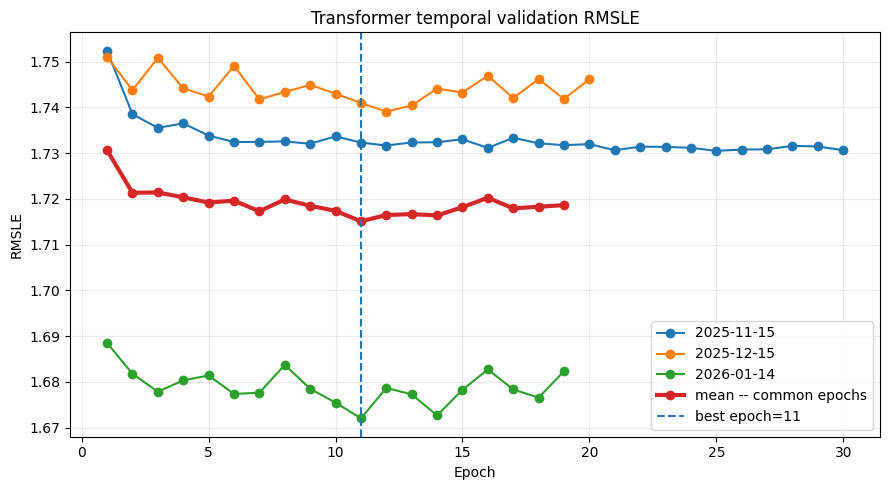

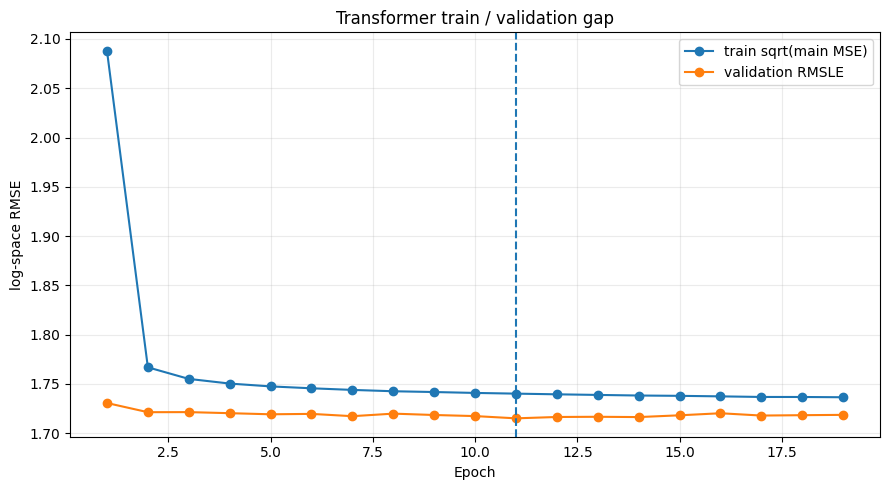

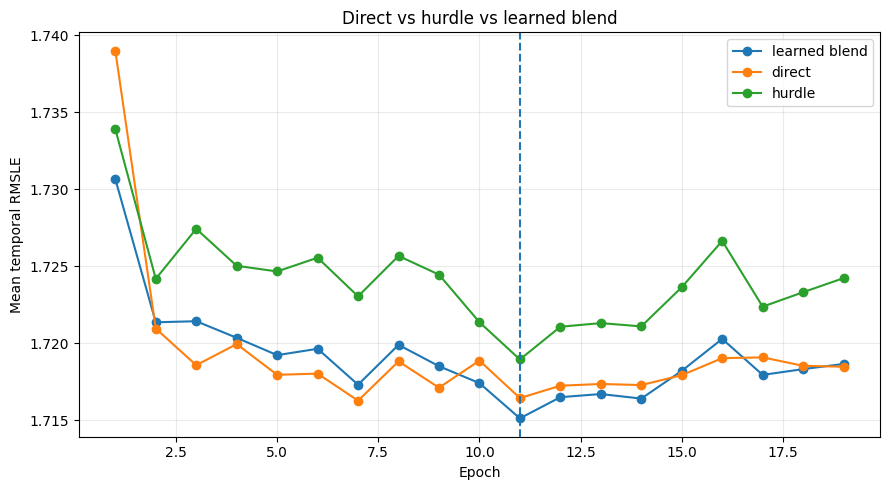

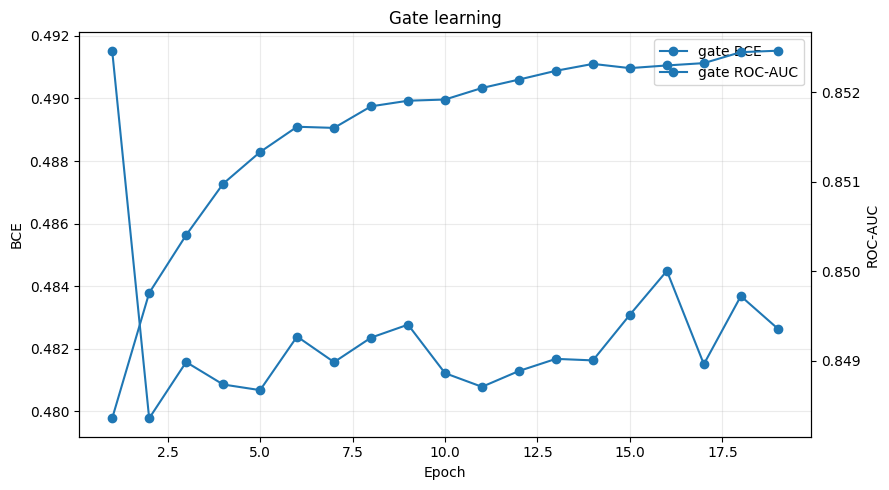

In [12]:
common_epochs = sorted(
    cv_summary["epoch"].unique()
)

common_df = cv_df[
    cv_df["epoch"].isin(common_epochs)
].copy()


# RMSLE по temporal fold.
fig, ax = plt.subplots(figsize=(9, 5))

for cutoff, part in cv_df.groupby("valid_cutoff"):
    part = part.sort_values("epoch")

    ax.plot(
        part["epoch"],
        part["rmsle"],
        marker="o",
        label=cutoff,
    )

mean_curve = (
    common_df.groupby("epoch")["rmsle"]
    .mean()
    .sort_index()
)

ax.plot(
    mean_curve.index,
    mean_curve.values,
    marker="o",
    linewidth=3,
    label="mean -- common epochs",
)

ax.axvline(
    BEST_EPOCH,
    linestyle="--",
    label=f"best epoch={BEST_EPOCH}",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("RMSLE")
ax.set_title("Transformer temporal validation RMSLE")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

fig.savefig(
    MODEL_DIR / "cv_rmsle_curve.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# Train vs validation.
fig, ax = plt.subplots(figsize=(9, 5))

train_mean = (
    common_df.groupby("epoch")["train_rmsle_proxy"]
    .mean()
    .sort_index()
)

valid_mean = (
    common_df.groupby("epoch")["rmsle"]
    .mean()
    .sort_index()
)

ax.plot(
    train_mean.index,
    train_mean.values,
    marker="o",
    label="train sqrt(main MSE)",
)

ax.plot(
    valid_mean.index,
    valid_mean.values,
    marker="o",
    label="validation RMSLE",
)

ax.axvline(
    BEST_EPOCH,
    linestyle="--",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("log-space RMSE")
ax.set_title("Transformer train / validation gap")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

fig.savefig(
    MODEL_DIR / "train_validation_gap.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# Direct vs hurdle vs blend.
fig, ax = plt.subplots(figsize=(9, 5))

curve = (
    common_df.groupby("epoch")[
        ["rmsle", "direct_rmsle", "hurdle_rmsle"]
    ]
    .mean()
    .sort_index()
)

ax.plot(
    curve.index,
    curve["rmsle"],
    marker="o",
    label="learned blend",
)

ax.plot(
    curve.index,
    curve["direct_rmsle"],
    marker="o",
    label="direct",
)

ax.plot(
    curve.index,
    curve["hurdle_rmsle"],
    marker="o",
    label="hurdle",
)

ax.axvline(
    BEST_EPOCH,
    linestyle="--",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean temporal RMSLE")
ax.set_title("Direct vs hurdle vs learned blend")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

fig.savefig(
    MODEL_DIR / "direct_hurdle_blend_curve.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# Gate BCE/AUC.
fig, ax = plt.subplots(figsize=(9, 5))

gate_curve = (
    common_df.groupby("epoch")[
        ["gate_bce", "gate_auc"]
    ]
    .mean()
    .sort_index()
)

line1 = ax.plot(
    gate_curve.index,
    gate_curve["gate_bce"],
    marker="o",
    label="gate BCE",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("BCE")

ax2 = ax.twinx()

line2 = ax2.plot(
    gate_curve.index,
    gate_curve["gate_auc"],
    marker="o",
    label="gate ROC-AUC",
)

ax2.set_ylabel("ROC-AUC")
ax.set_title("Gate learning")
ax.grid(alpha=0.25)

lines = line1 + line2

ax.legend(
    lines,
    [line.get_label() for line in lines],
    loc="best",
)

plt.tight_layout()

fig.savefig(
    MODEL_DIR / "gate_learning_curve.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

## 8. Error analysis -- что именно смотреть на January OOF

January -- самый свежий out-of-time fold.

После выбора **глобальной** `BEST_EPOCH` берутся January predictions именно этой эпохи.

Важно:

```text
global BEST_EPOCH
!= обязательно local January best
```

Final epoch выбирается по трем temporal months, а не по одному January.

### Главные сегменты

У LSTM самыми тяжелыми были:

```text
1. zero users, которым дали большой prediction
2. верхний positive tail -- whales
```

Поэтому здесь отдельно считаются:

- zero segment;
- positive quintiles по true `log1p(y)`;
- mean true log;
- mean predicted log;
- residual distribution;
- worst absolute errors;
- gate calibration.

Если Transformer имеет похожий overall RMSLE, но заметно другие ошибки на whales/zeros, это уже полезно для последующего blend.

### Почему смотрим log-space residual

Метрика:

$$
RMSLE =
\sqrt{
mean(
\log(1+\hat y)
-
\log(1+y)
)^2
}.
$$

Поэтому именно:

```text
residual =
pred_log - target_log
```

является естественной ошибкой модели.

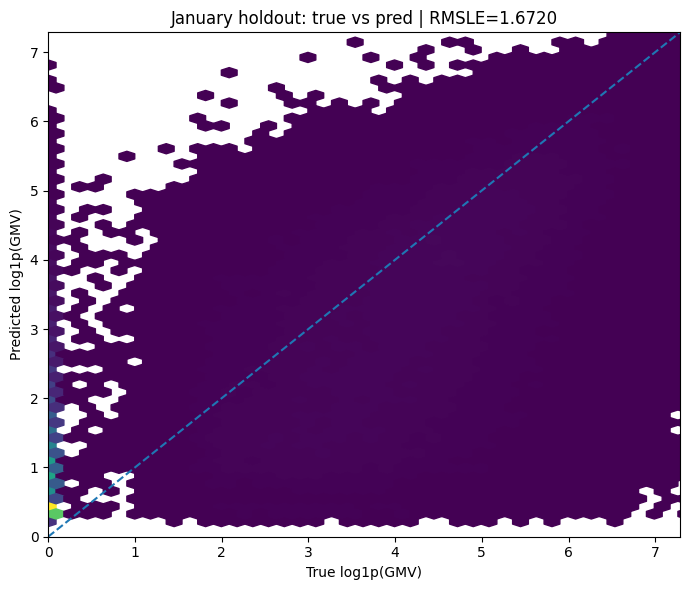

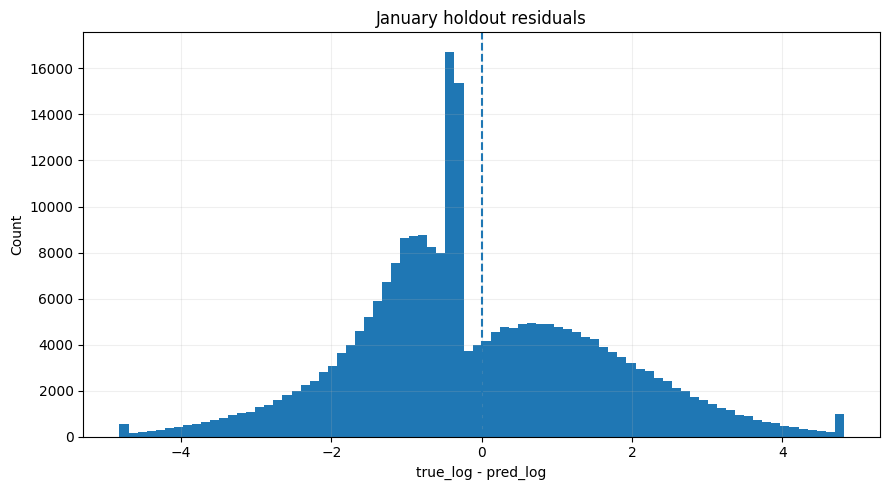

,segment,n,share,rmsle,mean_true_log,mean_pred_log,mean_residual
0,zero,114835,0.459340,1.637231,0.000000,1.324732,-1.324732
1,positive_Q1,27033,0.108132,1.189647,2.297012,2.244873,0.052139
2,positive_Q2,27033,0.108132,1.422873,3.374946,2.615267,0.759679
3,positive_Q3,27033,0.108132,1.663403,4.134425,3.037707,1.096719
4,positive_Q4,27033,0.108132,1.851124,4.881981,3.557427,1.324555
5,positive_Q5,27033,0.108132,2.198805,6.046467,4.354915,1.691552


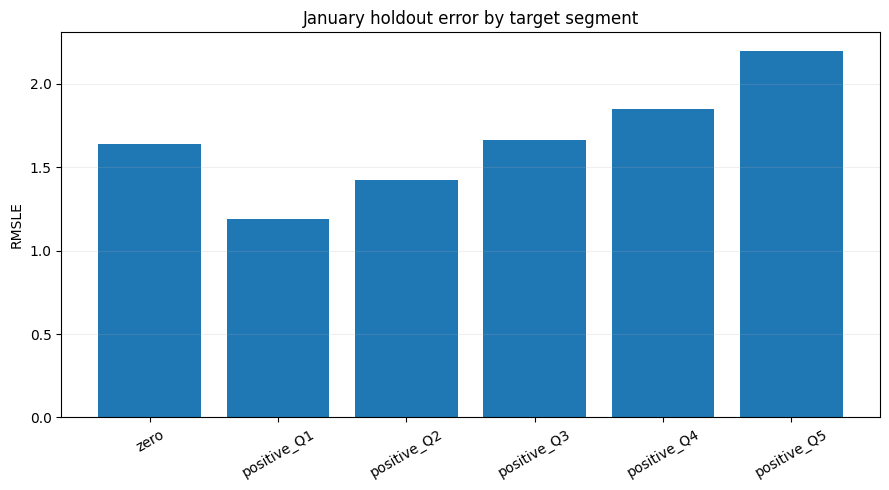

,bin,mean_pred,actual_rate,n
0,"(-0.001, 0.1]",0.095639,0.046197,1775
1,"(0.1, 0.2]",0.138326,0.098566,37670
2,"(0.2, 0.3]",0.251551,0.225342,29453
3,"(0.3, 0.4]",0.347572,0.349770,26992
4,"(0.4, 0.5]",0.449255,0.463801,22307
5,"(0.5, 0.6]",0.549661,0.558977,18024
6,"(0.6, 0.7]",0.650024,0.642232,17939
7,"(0.7, 0.8]",0.750936,0.725407,17007
8,"(0.8, 0.9]",0.851924,0.806045,21108
9,"(0.9, 1.0]",0.968596,0.935453,57725


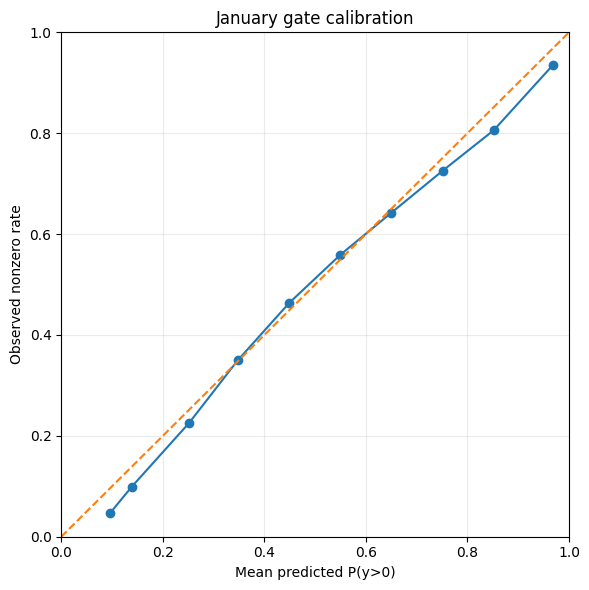

,user_id,y_true,y_pred,target_log,pred_log,residual_log,gate_prob,positive_log,direct_log,hurdle_log
97486,355760,5408.919922,0.561060,8.595989,0.445365,8.150624,0.141602,3.438877,0.391910,0.486950
134849,493918,3135.526123,0.516683,8.050871,0.416525,7.634346,0.129883,3.544921,0.360097,0.460424
144510,529470,2500.391846,0.606935,7.824603,0.474328,7.350274,0.150391,3.438877,0.419252,0.517175
74316,270681,9160.305664,5.454175,9.122744,1.864727,7.258017,0.453125,4.002808,1.930226,1.813772
104772,382829,3390.785645,1.422352,8.129112,0.884739,7.244373,0.249023,3.408646,0.930894,0.848833
146145,535525,3265.386475,1.448464,8.091439,0.895461,7.195978,0.248047,3.469139,0.940389,0.860509
182459,669690,1844.452148,0.438480,7.520480,0.363587,7.156893,0.126953,3.273004,0.296833,0.415518
84543,307751,1799.476929,0.502590,7.495807,0.407190,7.088616,0.128906,3.499431,0.350749,0.451098
86405,314582,1606.091431,0.435243,7.382181,0.361334,7.020847,0.119141,3.454005,0.296833,0.411512
67661,246472,3621.746094,2.257272,8.194987,1.180890,7.014097,0.296875,3.727473,1.276393,1.106593


In [13]:
best_pred = last_fold_prediction_store[BEST_EPOCH]

target_log = np.log1p(last_fold_y)
pred_log = np.clip(best_pred["pred_log"], 0, None)
pred_value = np.expm1(pred_log)

diag = pd.DataFrame({
    "user_id": last_fold_users,
    "y_true": last_fold_y,
    "y_pred": pred_value,
    "target_log": target_log,
    "pred_log": pred_log,
    "residual_log": target_log - pred_log,
    "sq_error_log": (target_log - pred_log) ** 2,
    "gate_prob": best_pred["gate_prob"],
    "positive_log": best_pred["positive_log"],
    "direct_log": best_pred["direct_log"],
    "hurdle_log": best_pred["hurdle_log"],
})
diag.to_csv(MODEL_DIR / "jan_holdout_diagnostics.csv", index=False)

# True vs pred в log1p.
fig, ax = plt.subplots(figsize=(7, 6))
ax.hexbin(diag["target_log"], diag["pred_log"], gridsize=60, mincnt=1)
limit = float(max(
    diag["target_log"].quantile(0.995),
    diag["pred_log"].quantile(0.995),
))
ax.plot([0, limit], [0, limit], linestyle="--")
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel("True log1p(GMV)")
ax.set_ylabel("Predicted log1p(GMV)")
ax.set_title(f"January holdout: true vs pred | RMSLE={JAN_RMSLE:.4f}")
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_true_vs_pred.png", dpi=160, bbox_inches="tight")
plt.show()

# Распределение residual.
fig, ax = plt.subplots(figsize=(9, 5))
clip = float(np.quantile(np.abs(diag["residual_log"]), 0.995))
ax.hist(diag["residual_log"].clip(-clip, clip), bins=80)
ax.axvline(0.0, linestyle="--")
ax.set_xlabel("true_log - pred_log")
ax.set_ylabel("Count")
ax.set_title("January holdout residuals")
ax.grid(alpha=0.20)
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_residual_hist.png", dpi=160, bbox_inches="tight")
plt.show()

# Нули + positive-квинтили.
diag["segment"] = "zero"
positive_idx = diag["y_true"] > 0
positive_rank = diag.loc[positive_idx, "target_log"].rank(method="first")
diag.loc[positive_idx, "segment"] = pd.qcut(
    positive_rank,
    q=5,
    labels=["positive_Q1", "positive_Q2", "positive_Q3", "positive_Q4", "positive_Q5"],
).astype(str)

segment_order = [
    "zero",
    "positive_Q1",
    "positive_Q2",
    "positive_Q3",
    "positive_Q4",
    "positive_Q5",
]

segment_rows = []
for segment in segment_order:
    part = diag[diag["segment"] == segment]
    if len(part) == 0:
        continue
    segment_rows.append({
        "segment": segment,
        "n": len(part),
        "share": len(part) / len(diag),
        "rmsle": float(np.sqrt(part["sq_error_log"].mean())),
        "mean_true_log": float(part["target_log"].mean()),
        "mean_pred_log": float(part["pred_log"].mean()),
        "mean_residual": float(part["residual_log"].mean()),
    })

segment_df = pd.DataFrame(segment_rows)
display(segment_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(segment_df["segment"], segment_df["rmsle"])
ax.set_ylabel("RMSLE")
ax.set_title("January holdout error by target segment")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.20)
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_segment_rmsle.png", dpi=160, bbox_inches="tight")
plt.show()

# Calibration gate.
calibration = pd.DataFrame({
    "p": diag["gate_prob"],
    "nonzero": (diag["y_true"] > 0).astype(float),
})
calibration["bin"] = pd.cut(
    calibration["p"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)
calibration_df = (
    calibration.groupby("bin", observed=True)
    .agg(
        mean_pred=("p", "mean"),
        actual_rate=("nonzero", "mean"),
        n=("nonzero", "size"),
    )
    .reset_index()
)
display(calibration_df)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(calibration_df["mean_pred"], calibration_df["actual_rate"], marker="o")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted P(y>0)")
ax.set_ylabel("Observed nonzero rate")
ax.set_title("January gate calibration")
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_gate_calibration.png", dpi=160, bbox_inches="tight")
plt.show()

worst_errors = (
    diag.assign(abs_error=lambda x: np.abs(x["residual_log"]))
    .sort_values("abs_error", ascending=False)
    .head(30)
    [[
        "user_id",
        "y_true",
        "y_pred",
        "target_log",
        "pred_log",
        "residual_log",
        "gate_prob",
        "positive_log",
        "direct_log",
        "hurdle_log",
    ]]
)
display(worst_errors)

## 9. Screening относительно текущей LSTM

Reference:

```text
Joint Hurdle BiLSTM expanded ES
mean temporal CV = 1.715708
January          = 1.677522
Public           = 1.6506631932
```

CV Transformer сравнивается с этими значениями.

Но final train **не отключается автоматически** при небольшом проигрыше.

Причина практическая: последний LSTM run локально был немного хуже предыдущего, но public все равно улучшился.

Разницы порядка `1e-3` уже нельзя считать надежным сигналом "не запускать final".

Поэтому:

```text
CV -- sanity / ranking signal
public -- финальная проверка submission
```

Ручной stop имеет смысл только если Transformer явно провалился на несколько сотых RMSLE.

In [14]:
cv_delta = CV_RMSLE - REFERENCE_MEAN_CV_RMSLE
jan_delta = JAN_RMSLE - REFERENCE_JAN_HOLDOUT_RMSLE

print(
    "LSTM reference mean CV:",
    f"{REFERENCE_MEAN_CV_RMSLE:.6f}",
)
print(
    "Transformer mean CV:",
    f"{CV_RMSLE:.6f}",
)
print(
    "delta:",
    f"{cv_delta:+.6f}",
)

print()

print(
    "LSTM reference January:",
    f"{REFERENCE_JAN_HOLDOUT_RMSLE:.6f}",
)
print(
    "Transformer January:",
    f"{JAN_RMSLE:.6f}",
)
print(
    "delta:",
    f"{jan_delta:+.6f}",
)

if cv_delta < 0:
    print("\nTransformer improves mean temporal CV.")
elif abs(cv_delta) <= 0.003:
    print("\nTransformer is still in the competitive CV zone.")
else:
    print("\nWARNING: Transformer is materially worse on temporal CV.")

# Для первого Transformer run final train не скипаю автоматически.
SHOULD_RUN_FINAL = (
    FORCE_FINAL_TRAIN
    or not AUTO_SKIP_FINAL_IF_WEAK
)

print(
    "FINAL TRAIN:",
    "ENABLED"
    if SHOULD_RUN_FINAL
    else "SKIPPED",
)

LSTM reference mean CV: 1.715708
Transformer mean CV: 1.715113
delta: -0.000595

LSTM reference January: 1.677522
Transformer January: 1.672047
delta: -0.005475

Transformer improves mean temporal CV.
FINAL TRAIN: ENABLED


## 10. Final train -- три seed на всех labeled data

После CV известен:

```text
BEST_EPOCH
```

CV weights для submission не используются.

Почему?

Например January CV model обучалась только на:

```text
Apr..Dec
```

и специально не видела January target.

Final model должна использовать все доступные labels:

```text
Apr..Jan
```

Поэтому создаются **три новые модели с нуля**:

```text
seed 42
seed 143
seed 2026
```

Каждая получает:

```text
все labeled cutoff
x
BEST_EPOCH epochs
```

### Почему final early stopping нет

Early stopping требует validation set.

Если оставить January для validation, final model потеряет January как training data.

Temporal CV уже выбрала число эпох, поэтому final stage просто использует этот hyperparameter.

### Зачем три seed

Одна architecture из-за initialization / shuffle / dropout дает немного разные решения.

У нас нет честного основания выбирать один seed как лучший на test.

Поэтому все три predictions усредняются.

Это уменьшает variance и обычно надежнее одной случайной траектории.

### Scheduler consistency

CV использует:

```text
CosineAnnealingLR(T_max=30)
```

Если `BEST_EPOCH=8`, final model тоже проходит **первые 8 эпох trajectory с T_max=30**.

Нельзя заменить на `T_max=8`, потому что тогда LR по эпохам изменится и final training regime уже не будет тем, который проверяла CV.

In [15]:
final_static_stats = fit_static_stats(
    LABELED_CUTOFFS
)

final_known_user_mask = (
    known_user_mask_from_cutoffs(
        LABELED_CUTOFFS
    )
)

final_models = []


FINAL_TRAIN_SIGNATURE = hashlib.sha256(
    json.dumps(
        {
            "architecture": "JointHurdleTransformer-v1",
            "model_kwargs": MODEL_KWARGS,
            "batch_size": BATCH_SIZE,
            "best_epoch": BEST_EPOCH,
            "scheduler_t_max": MAX_CV_EPOCHS,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "adam_betas": ADAM_BETAS,
            "aux_weights": {
                "gate": AUX_GATE_WEIGHT,
                "positive": AUX_POS_WEIGHT,
                "direct": AUX_DIRECT_WEIGHT,
            },
            "flags": {
                "user_embedding": USE_USER_EMBEDDING,
                "absolute_time": USE_ABSOLUTE_TIME,
                "future_calendar": USE_FUTURE_CALENDAR_STATIC,
                "cutoff_seasonal": USE_CUTOFF_SEASONAL_STATIC,
            },
        },
        sort_keys=True,
        default=str,
    ).encode("utf-8")
).hexdigest()[:16]


def _load_resume(path, map_location="cpu"):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location,
        )


def _save_resume_checkpoint(
    path,
    seed,
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    history,
):
    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    payload = {
        "architecture": "JointHurdleTransformer-v1",
        "training_signature": FINAL_TRAIN_SIGNATURE,
        "seed": int(seed),
        "epoch": int(epoch),
        "best_epoch": int(BEST_EPOCH),
        "scheduler_t_max": int(MAX_CV_EPOCHS),
        "model_kwargs": MODEL_KWARGS,
        "state_dict": {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        },
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": (
            scaler.state_dict()
            if scaler is not None
            else None
        ),
        "history": history,
        "rng_state": capture_rng_state(),
    }

    tmp = path.with_suffix(".tmp")
    torch.save(payload, tmp)
    tmp.replace(path)


def _save_final_seed(
    model,
    path,
    seed,
    trained_epochs,
):
    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    torch.save(
        {
            "architecture": "JointHurdleTransformer-v1",
            "training_signature": FINAL_TRAIN_SIGNATURE,
            "seed": int(seed),
            "trained_epochs": int(trained_epochs),
            "scheduler_t_max": int(MAX_CV_EPOCHS),
            "model_kwargs": MODEL_KWARGS,
            "state_dict": {
                key: value.detach().cpu()
                for key, value in model.state_dict().items()
            },
        },
        path,
    )


def _final_checkpoint_is_current(path):
    if not path.exists():
        return False

    try:
        checkpoint = _load_resume(
            path,
            map_location="cpu",
        )
    except Exception:
        return False

    return (
        checkpoint.get("architecture")
        == "JointHurdleTransformer-v1"
        and checkpoint.get("training_signature")
        == FINAL_TRAIN_SIGNATURE
        and int(
            checkpoint.get("trained_epochs", -1)
        )
        == int(BEST_EPOCH)
    )


if SHOULD_RUN_FINAL:
    for seed in FINAL_SEEDS:
        print("\n" + "=" * 100)
        print("FINAL SEED:", seed)

        seed_dir = (
            MODEL_DIR
            / f"seed_{seed}"
        )

        seed_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        resume_path = seed_dir / "resume.pt"
        final_path = seed_dir / "model.pt"
        history_path = seed_dir / "history.json"

        if _final_checkpoint_is_current(final_path):
            print(
                f"seed {seed}: current final model exists -> skip"
            )

            checkpoint = _load_resume(
                final_path,
                map_location=DEVICE,
            )

            model = JointHurdleTransformer(
                **checkpoint["model_kwargs"]
            ).to(DEVICE)

            model.load_state_dict(
                checkpoint["state_dict"],
                strict=True,
            )

            model.eval()

            history = (
                json.loads(
                    history_path.read_text(
                        encoding="utf-8"
                    )
                )
                if history_path.exists()
                else []
            )

            final_models.append(
                (seed, model, history)
            )

            continue

        if final_path.exists():
            print(
                f"seed {seed}: stale final model ignored"
            )

        set_seed(seed)

        train_loader = make_loader(
            LABELED_CUTOFFS,
            shuffle=True,
            known_user_mask=final_known_user_mask,
        )

        model = JointHurdleTransformer(
            **MODEL_KWARGS
        ).to(DEVICE)

        optimizer = make_optimizer(model)
        scaler = new_grad_scaler()

        # ВАЖНО: тот же schedule horizon, что и в CV.
        scheduler = (
            torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer,
                T_max=MAX_CV_EPOCHS,
                eta_min=2e-5,
            )
        )

        history = []
        start_epoch = 1

        if resume_path.exists():
            checkpoint = _load_resume(
                resume_path,
                map_location=DEVICE,
            )

            if (
                checkpoint.get("architecture")
                == "JointHurdleTransformer-v1"
                and checkpoint.get("training_signature")
                == FINAL_TRAIN_SIGNATURE
            ):
                model.load_state_dict(
                    checkpoint["state_dict"],
                    strict=True,
                )

                optimizer.load_state_dict(
                    checkpoint["optimizer_state_dict"]
                )

                scheduler.load_state_dict(
                    checkpoint["scheduler_state_dict"]
                )

                if (
                    scaler is not None
                    and checkpoint.get("scaler_state_dict")
                    is not None
                ):
                    scaler.load_state_dict(
                        checkpoint["scaler_state_dict"]
                    )

                history = checkpoint.get(
                    "history",
                    [],
                )

                start_epoch = (
                    int(checkpoint["epoch"])
                    + 1
                )

                restore_rng_state(
                    checkpoint.get("rng_state")
                )

                print(
                    f"RESUME: epoch {checkpoint['epoch']} completed "
                    f"-> start from {start_epoch}"
                )

            else:
                print(
                    f"seed {seed}: stale resume checkpoint ignored"
                )

        for epoch in range(
            start_epoch,
            BEST_EPOCH + 1,
        ):
            train_metrics = train_one_epoch(
                model,
                train_loader,
                optimizer,
                final_static_stats,
                scaler,
            )

            scheduler.step()

            history.append({
                "epoch": int(epoch),
                "lr": float(
                    optimizer.param_groups[0]["lr"]
                ),
                **{
                    key: float(value)
                    for key, value
                    in train_metrics.items()
                },
            })

            _save_resume_checkpoint(
                resume_path,
                seed,
                epoch,
                model,
                optimizer,
                scheduler,
                scaler,
                history,
            )

            history_path.write_text(
                json.dumps(
                    history,
                    ensure_ascii=False,
                    indent=2,
                ),
                encoding="utf-8",
            )

            print(
                f"epoch {epoch:02d}/{BEST_EPOCH:02d} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e} | "
                f"loss={train_metrics['loss']:.5f} | "
                f"main_RMSE="
                f"{np.sqrt(max(train_metrics['main_mse'], 0)):.5f} | "
                "checkpoint SAVED"
            )

        _save_final_seed(
            model,
            final_path,
            seed,
            BEST_EPOCH,
        )

        print(
            "FINAL WEIGHTS SAVED:",
            final_path,
        )

        final_models.append(
            (seed, model, history)
        )

else:
    print(
        "No final models trained."
    )


FINAL SEED: 42
epoch 01/11 | lr=2.00e-04 | loss=4.70909 | main_RMSE=2.02557 | checkpoint SAVED
epoch 02/11 | lr=1.98e-04 | loss=3.40642 | main_RMSE=1.75620 | checkpoint SAVED
epoch 03/11 | lr=1.96e-04 | loss=3.36575 | main_RMSE=1.74665 | checkpoint SAVED
epoch 04/11 | lr=1.92e-04 | loss=3.34684 | main_RMSE=1.74233 | checkpoint SAVED
epoch 05/11 | lr=1.88e-04 | loss=3.33642 | main_RMSE=1.74004 | checkpoint SAVED
epoch 06/11 | lr=1.83e-04 | loss=3.32753 | main_RMSE=1.73799 | checkpoint SAVED
epoch 07/11 | lr=1.77e-04 | loss=3.32157 | main_RMSE=1.73667 | checkpoint SAVED
epoch 08/11 | lr=1.70e-04 | loss=3.31643 | main_RMSE=1.73549 | checkpoint SAVED
epoch 09/11 | lr=1.63e-04 | loss=3.31175 | main_RMSE=1.73443 | checkpoint SAVED
epoch 10/11 | lr=1.55e-04 | loss=3.30839 | main_RMSE=1.73365 | checkpoint SAVED
epoch 11/11 | lr=1.47e-04 | loss=3.30572 | main_RMSE=1.73307 | checkpoint SAVED
FINAL WEIGHTS SAVED: /content/drive/MyDrive/Colab-Notebooks/E-CUP-2026/models/transformer_hurdle_v1/seed

## 11. Какие artifacts сохраняются

Основной каталог:

```text
models/transformer_hurdle_v1/
```

Ключевые файлы:

```text
config.json
model.pt
static_stats.pt

cv_history.csv
cv_summary.csv
cv_fold_stops.csv

oof_best_epoch.parquet

data_meta.json
all_user_ids.npy
```

### CV state

```text
cv_state/
  fold_1_.../
    resume.pt
    prediction_epoch_01.npz
    prediction_epoch_02.npz
    ...

  fold_2_.../
  fold_3_.../
```

То есть exact per-user OOF сохраняется **сразу в процессе CV**.

### Final seeds

```text
seed_42/
  resume.pt
  model.pt
  history.json

seed_143/
seed_2026/
```

`model.pt` в корне -- primary seed для удобного reload smoke-test.

### Что хранить в GitHub

`config.json`, notebook, summary CSV и при необходимости финальные model weights -- полезные artifacts.

Per-epoch OOF `.npz` могут занять сотни MB. Их логичнее держать на Drive / artifact storage, если GitHub начинает раздуваться.

In [16]:
def save_checkpoint(model, path, seed):
    path.parent.mkdir(parents=True, exist_ok=True)

    payload = {
        "architecture": "JointHurdleTransformer-v1",
        "training_signature": FINAL_TRAIN_SIGNATURE,
        "seed": int(seed),
        "trained_epochs": int(BEST_EPOCH),
        "scheduler_t_max": int(MAX_CV_EPOCHS),
        "model_kwargs": MODEL_KWARGS,
        "state_dict": {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        },
    }

    torch.save(payload, path)


meta_bytes = (DATA_DIR / "meta.json").read_bytes()

cv_df.to_csv(MODEL_DIR / "cv_history.csv", index=False)
cv_summary.to_csv(MODEL_DIR / "cv_summary.csv", index=False)

shutil.copy2(DATA_DIR / "meta.json", MODEL_DIR / "data_meta.json")
shutil.copy2(DATA_DIR / "all_user_ids.npy", MODEL_DIR / "all_user_ids.npy")

if final_models:
    for seed, model, history in final_models:
        save_checkpoint(
            model,
            MODEL_DIR / f"seed_{seed}" / "model.pt",
            seed,
        )

    primary_seed, primary_model, _ = final_models[0]
    save_checkpoint(primary_model, MODEL_DIR / "model.pt", primary_seed)

    torch.save(
        {
            "mean": final_static_stats[0].cpu(),
            "std": final_static_stats[1].cpu(),
            "selected_static_features": STATIC_FEATURES,
        },
        MODEL_DIR / "static_stats.pt",
    )

config = {
    "architecture": "JointHurdleTransformer-v1",
    "data_format_version": META["format_version"],
    "data_meta_sha256": hashlib.sha256(meta_bytes).hexdigest(),
    "model_kwargs": MODEL_KWARGS,
    "static_features": STATIC_FEATURES,
    "flags": {
        "use_user_embedding": USE_USER_EMBEDDING,
                "use_absolute_time": USE_ABSOLUTE_TIME,
        "use_future_calendar_static": USE_FUTURE_CALENDAR_STATIC,
        "use_cutoff_seasonal_static": USE_CUTOFF_SEASONAL_STATIC,
    },
    "optimizer": "AdamW",
    "adam_betas": ADAM_BETAS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "embedding_lr": EMBED_LR,
    "weight_decay": WEIGHT_DECAY,
    "embedding_weight_decay": EMBED_WEIGHT_DECAY,
    "aux_weights": {
        "gate": AUX_GATE_WEIGHT,
        "positive": AUX_POS_WEIGHT,
        "direct": AUX_DIRECT_WEIGHT,
    },
    "cv_valid_cutoffs": CV_VALID_CUTOFFS,
    "best_epoch": BEST_EPOCH,
    "max_cv_epochs": MAX_CV_EPOCHS,
    "last_common_epoch": LAST_COMMON_EPOCH,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
    "min_cv_epochs_before_stop": MIN_CV_EPOCHS_BEFORE_STOP,
    "scheduler_t_max": MAX_CV_EPOCHS,
    "training_signature": FINAL_TRAIN_SIGNATURE,
    "mean_temporal_cv_rmsle": CV_RMSLE,
    "cv_std_rmsle": CV_STD,
    "january_rmsle": JAN_RMSLE,
    "reference_lstm_mean_cv_rmsle": REFERENCE_MEAN_CV_RMSLE,
    "reference_lstm_january_rmsle": REFERENCE_JAN_HOLDOUT_RMSLE,
    "reference_lstm_public_rmsle": REFERENCE_PUBLIC_RMSLE,
    "final_train_ran": bool(final_models),
    "final_seeds": FINAL_SEEDS if final_models else [],
    "prediction_space": "log1p",
    "final_ensemble": (
        "mean pred_log across seeds, then expm1"
        if final_models
        else None
    ),
    "sequence_input_size": SEQ_INPUT_SIZE,
    "short_summary_size": SHORT_SUMMARY_SIZE,
    "static_input_size": STATIC_INPUT_SIZE,
    "oof_path": str(OOF_PATH.relative_to(PROJECT_ROOT)),
}

with open(MODEL_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("saved artifacts to:", MODEL_DIR)

saved artifacts to: /content/drive/MyDrive/Colab-Notebooks/E-CUP-2026/models/transformer_hurdle_v1


## 12. Inference и three-seed ensemble

Каждая final model независимо считает:

```text
pred_log
gate_prob
positive_log
direct_log
hurdle_log
```

Компоненты каждого seed сохраняются в:

```text
inference_seed_42.npz
inference_seed_143.npz
inference_seed_2026.npz
```

Это пригодится для diagnostics / blending без повторного inference.

### Финальный ensemble

Сначала в log-space:

$$
ensemble\_pred\_log =
\frac{
pred\_log_{42}
+
pred\_log_{143}
+
pred\_log_{2026}
}{3}.
$$

Потом:

$$
predict =
\exp(
ensemble\_pred\_log
)-1.
$$

Усреднять лучше до `expm1`, потому что:

- loss обучается в `log1p`-space;
- RMSLE измеряет расстояния там же.

### Seed diagnostics

Дополнительно считается:

- pairwise correlation seed predictions;
- mean per-user standard deviation;
- p95 per-user standard deviation.

Если seed predictions почти идентичны, третий seed дает мало нового.

Если разброс большой, ensemble особенно полезен.

In [17]:
if final_models:
    seed_pred_logs = []
    seed_names = []
    submission_user_ids = None

    for seed, model, _ in final_models:
        user_ids, pred, _ = predict_model(
            model,
            INFERENCE_CUTOFF,
            final_static_stats,
            final_known_user_mask,
            with_target=False,
        )

        seed_log = np.clip(
            pred["pred_log"],
            0,
            None,
        )

        seed_pred_logs.append(
            seed_log
        )
        seed_names.append(
            str(seed)
        )
        submission_user_ids = user_ids

        np.savez_compressed(
            MODEL_DIR / f"inference_seed_{seed}.npz",
            user_id=user_ids,
            **pred,
        )

    seed_matrix = np.stack(
        seed_pred_logs,
        axis=1,
    )

    seed_corr = pd.DataFrame(
        seed_matrix,
        columns=seed_names,
    ).corr()

    print("pairwise pred_log correlation:")
    display(seed_corr)

    seed_std = seed_matrix.std(axis=1)

    print(
        "mean per-user seed std:",
        f"{seed_std.mean():.6f}",
    )
    print(
        "p95 per-user seed std:",
        f"{np.quantile(seed_std, 0.95):.6f}",
    )

    ensemble_pred_log = (
        seed_matrix.mean(axis=1)
    )

    raw_pred = np.expm1(
        ensemble_pred_log
    )

    submission = pd.read_csv(
        PROJECT_ROOT
        / "data"
        / "sample_submit.csv"
    )

    pred_map = pd.Series(
        raw_pred,
        index=submission_user_ids,
    )

    submission["predict"] = (
        submission["user_id"]
        .map(pred_map)
    )

    if submission["predict"].isna().any():
        raise AssertionError(
            "Missing predictions: "
            f"{int(submission['predict'].isna().sum())}"
        )

    if not np.isfinite(
        submission["predict"]
    ).all():
        raise AssertionError(
            "Non-finite predictions"
        )

    if (
        submission["predict"] < 0
    ).any():
        raise AssertionError(
            "Negative predictions are forbidden"
        )

    out_path = (
        SUBMISSION_DIR
        / "transformer_hurdle_v1_3seed.csv"
    )

    submission.to_csv(
        out_path,
        index=False,
    )

    print("saved:", out_path)
    print("rows:", len(submission))
    print(
        "exact zeros:",
        f"{(submission['predict'] == 0).mean():.2%}",
    )

    display(
        submission.head()
    )

else:
    print(
        "Submission skipped because final training was skipped."
    )

pairwise pred_log correlation:


,42,143,2026
42,1.000000,0.998992,0.998456
143,0.998992,1.000000,0.998800
2026,0.998456,0.998800,1.000000


mean per-user seed std: 0.062976
p95 per-user seed std: 0.124152
saved: /content/drive/MyDrive/Colab-Notebooks/E-CUP-2026/submissions/transformer_hurdle_v1_3seed.csv
rows: 250000
exact zeros: 0.00%


,user_id,predict
0,2,1.950553
1,7,89.969757
2,15,6.853100
3,18,126.861832
4,23,0.383231


## 13. Reload smoke-test

Последняя техническая проверка нужна, чтобы модель была воспроизводима **после смерти текущего kernel**.

Проверяется:

```text
1. checkpoint читается с диска
2. architecture создается из model_kwargs
3. state_dict загружается strict=True
4. static stats читаются с диска
5. выполняется новый inference batch
6. pred_log / gate / positive / direct / hurdle конечные
```

Также печатаются:

```text
learned hurdle_weight
learned recency pooling bias
```

Если smoke-test прошел, финальные artifacts пригодны для отдельного inference notebook/script.

In [18]:
def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)


def load_saved_model(path):
    checkpoint = safe_torch_load(path, map_location=DEVICE)
    if checkpoint.get("architecture") != "JointHurdleTransformer-v1":
        raise RuntimeError("Unexpected checkpoint architecture")

    model = JointHurdleTransformer(**checkpoint["model_kwargs"]).to(DEVICE)
    model.load_state_dict(checkpoint["state_dict"], strict=True)
    model.eval()
    return model


if final_models:
    saved_stats = safe_torch_load(MODEL_DIR / "static_stats.pt", map_location="cpu")
    loaded_stats = (saved_stats["mean"], saved_stats["std"])
    loaded_model = load_saved_model(MODEL_DIR / "model.pt")

    smoke_dataset = HybridDataset(
        INFERENCE_CUTOFF,
        with_target=False,
        known_user_mask=final_known_user_mask,
    )
    smoke_loader = DataLoader(
        smoke_dataset,
        batch_size=min(256, BATCH_SIZE),
        shuffle=False,
        num_workers=0,
    )
    smoke_batch = next(iter(smoke_loader))

    sequence, static, user_index, user_known, history_length, _ = unpack_batch(
        smoke_batch,
        with_target=False,
    )
    static = normalize_static(static, loaded_stats)

    with torch.no_grad():
        out = loaded_model(
            sequence,
            static,
            user_index,
            user_known,
            history_length,
        )

    for key in ["pred_log", "gate_prob", "positive_log", "direct_log"]:
        assert torch.isfinite(out[key]).all(), key

    print("reload smoke-test passed:", len(out["pred_log"]), "rows")
    print("saved hurdle weight:", float(out["hurdle_weight"].cpu()))
    print("saved user scale:", float(out["user_scale"].cpu()))
    print(
        "saved recency pooling bias:",
        float(loaded_model.recency_attention_bias.detach().cpu()),
    )
else:
    print("Reload test skipped: no final checkpoint was trained.")

reload smoke-test passed: 256 rows
saved hurdle weight: 0.5599774122238159
saved user scale: 0.0
saved recency pooling bias: 0.26937180757522583


# Итог -- что именно проверяет этот experiment

Это не попытка "накидать Transformer и одновременно поменять все".

Controlled difference:

```text
Joint Hurdle BiLSTM
        |
        v
Joint Hurdle Transformer
```

При этом сохраняются:

- target;
- 90-day history;
- feature engineering;
- short-summary branch;
- static branch;
- three-head hurdle/direct formulation;
- auxiliary losses;
- temporal validation;
- final seed ensemble.

## Критерии успеха после run

### 1. Standalone quality

Главное сравнение:

```text
Transformer mean temporal CV
vs
1.715708 LSTM

Transformer January
vs
1.677522 LSTM
```

И затем public против:

```text
1.6506631932
```

### 2. Training regime

Желательно:

```text
BEST_EPOCH < LAST_COMMON_EPOCH
```

Если selected epoch опять последняя общая -- training horizon потенциально мал.

### 3. Heads

Смотрим:

```text
blend RMSLE
direct RMSLE
hurdle RMSLE
hurdle_weight
```

Если learned blend стабильно лучше обеих веток, multi-task decomposition работает и для Transformer.

### 4. Tail

Особенно важен upper positive quintile.

Последняя LSTM систематически недооценивала крупных будущих spenders.

Если Transformer исправляет часть tail, он может оказаться полезен даже при почти равном overall RMSLE.

### 5. Diversity

После этого run у нас сразу есть:

```text
oof_best_epoch.parquet
```

Поэтому Transformer можно **без retrain** сравнить с LSTM по:

- residual correlation;
- optimal log-space blend;
- gate disagreement;
- whale errors;
- zero errors.

Это особенно важно после неудачного старого stacking: новая architecture имеет смысл только если дает либо лучший standalone quality, либо реально другой residual pattern.

## Что не менять до первого полного результата

Не стоит одновременно трогать:

```text
d_model
depth
heads
loss weights
user embedding
future calendar
new target transforms
```

Сначала нужен один законченный baseline этой architecture.

Текущая конфигурация специально выбрана как достаточно сильный, но консервативный first Transformer run:

```text
d_model = 128
heads = 8
layers = 3
FFN = 384
dropout = 0.15
```

При sequence length 90 она должна нормально помещаться и обучаться на обычном Colab GPU.